In [1]:
#let colab access my google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import the libraries

In [2]:
# import warnings

# warnings.filterwarnings("ignore")

#Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

#Libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

#Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
#Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
#Setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)




# Load the dataset

In [3]:
hotel=pd.read_csv('/content/drive/MyDrive/project python 3/INNHotelsGroup.csv')

In [4]:
#Make a copy of the dataset to avoid any other changes to the original dataset
data = hotel.copy()

# Overview of Dataset

In [5]:
#First 5 rows of the dataset
data.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [6]:
#Last 5 rows of the dataset
data.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


# Understand the shape of Dataset

In [7]:
#Shape of the dataset
data.shape

(36275, 19)

The dataset has 36275 rows and 19 columns.

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

# Observation:

The dataset contains both numerical and categorical variables. Categorical variables include Booking_ID, type_of_meal_plan, room_type_reserved, market_segment_type, and booking_status, while the remaining variables are numerical. The dataset contains no missing values.

# Duplicate Value Check

In [9]:
#Checking for duplicate values
data.duplicated().sum()

np.int64(0)

# Dropping Booking_ID Column

In [10]:
#Drop Booking-ID so we can move foward
data.drop('Booking_ID',axis=1,inplace=True)
data.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


# Statistical Summary

In [11]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00000,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
required_car_parking_space,36275.00000,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
lead_time,36275.00000,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000
arrival_month,36275.00000,7.42365,3.06989,1.00000,5.00000,8.00000,10.00000,12.00000
arrival_date,36275.00000,15.59700,8.74045,1.00000,8.00000,16.00000,23.00000,31.00000
repeated_guest,36275.00000,0.02564,0.15805,0.00000,0.00000,0.00000,0.00000,1.00000


# Observation:

The number of adults ranges from 0 to 4.

The maximum value in the number of children column is 10,which is unusual.

The range of the number of weeks and weekend nights seems fine.But 7 weekends nights quite long stay.

The car parking space do not require by 75% of customers.

On average customers book rooms 85 days in advance .So there is huge difference between 75 percentile and maximum value.So may be outliers present in data.

Atleast 75% of customers are not repeating customers.

The average price per room is 103 euros .There's a huge difference between the 75th percentile and the maximum value .So may be outliers present in data.

# Q-1 Exploratory Data Analysis

# Problem Definition
INN Hotels Group has a chain of hotels in Portugal, and they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. As a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which bookings are going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

# Univariate Analysis

# Function To create Histogram and Boxplot

In [12]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
        )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

# Observation On lead_time

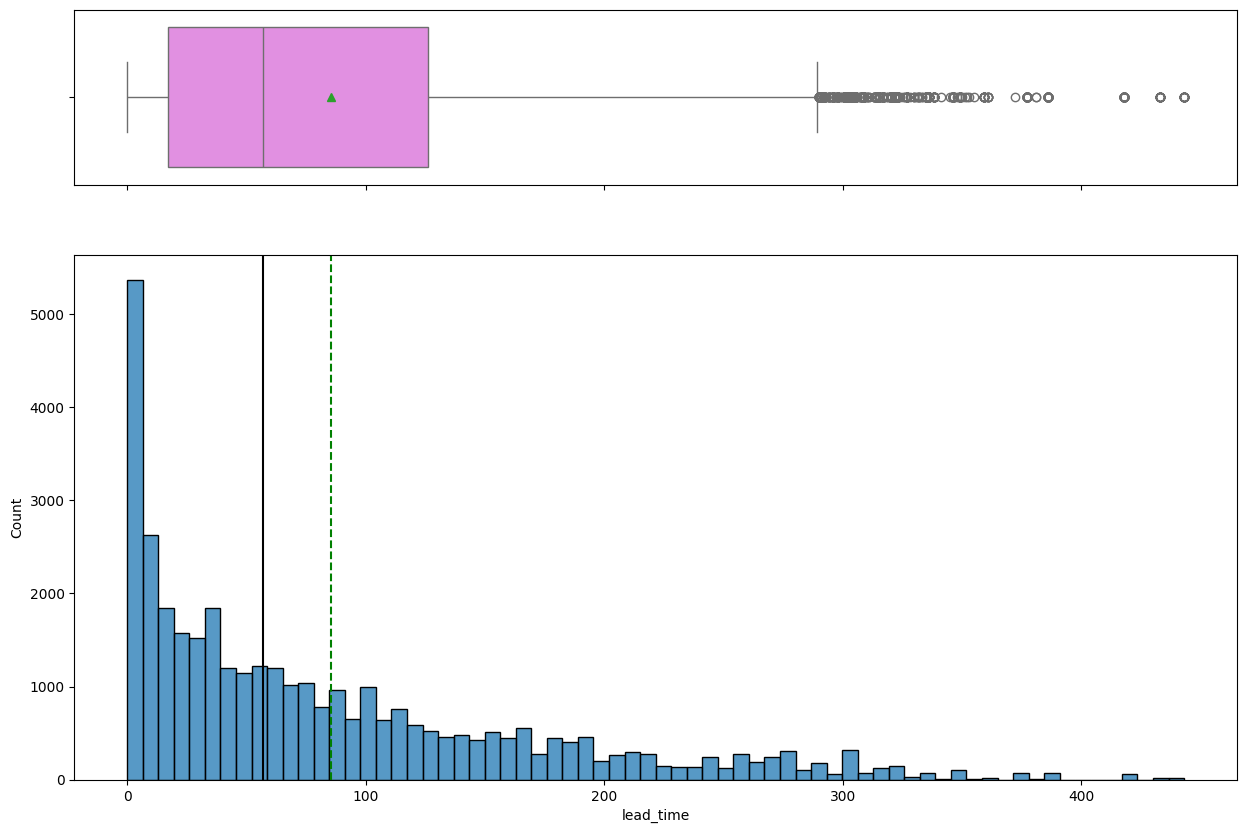

In [13]:
histogram_boxplot(data,'lead_time')

# Observation on lead time

The distribution of lead time is right-skewed, indicating that most bookings are made closer to the arrival date.

There are outliers with very long lead times, suggesting some bookings are made well in advance.

The majority of lead times are concentrated between 0 and 150 days.


# Observation on avg_price_per_room

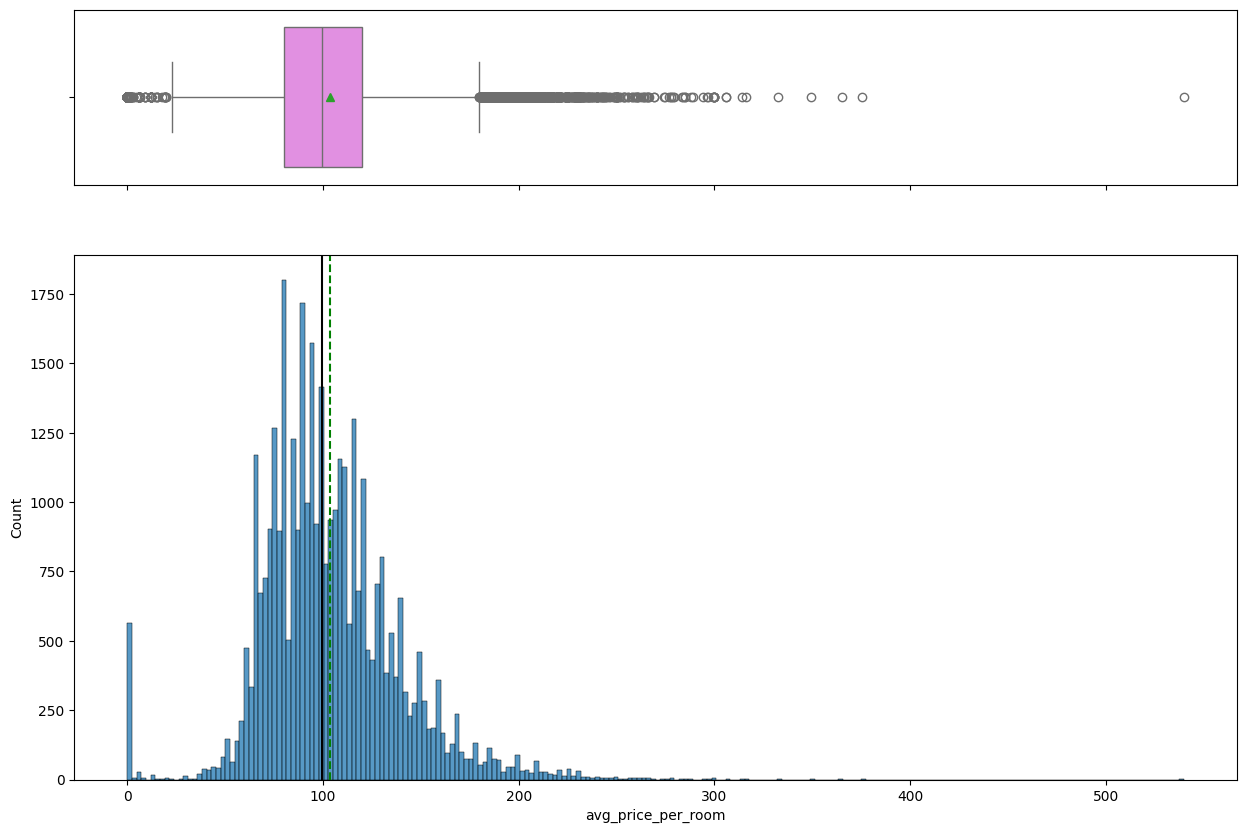

In [14]:
histogram_boxplot(data,'avg_price_per_room')

# Observation:
The distribution of average price per room is skewed to the right, with a peak around 100 euros.

There are outliers with very high average prices, which could be due to special room types or peak seasons.

The majority of average prices are between 50 and 150 euros. Some rooms have a price equal to 0(needs to be checked)


# Checking The room where average price of room is equal to zero

In [15]:
data[data['avg_price_per_room']==0]

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
63,1,0,0,1,Meal Plan 1,0,Room_Type 1,2,2017,9,10,Complementary,0,0,0,0.00000,1,Not_Canceled
145,1,0,0,2,Meal Plan 1,0,Room_Type 1,13,2018,6,1,Complementary,1,3,5,0.00000,1,Not_Canceled
209,1,0,0,0,Meal Plan 1,0,Room_Type 1,4,2018,2,27,Complementary,0,0,0,0.00000,1,Not_Canceled
266,1,0,0,2,Meal Plan 1,0,Room_Type 1,1,2017,8,12,Complementary,1,0,1,0.00000,1,Not_Canceled
267,1,0,2,1,Meal Plan 1,0,Room_Type 1,4,2017,8,23,Complementary,0,0,0,0.00000,1,Not_Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35983,1,0,0,1,Meal Plan 1,0,Room_Type 7,0,2018,6,7,Complementary,1,4,17,0.00000,1,Not_Canceled
36080,1,0,1,1,Meal Plan 1,0,Room_Type 7,0,2018,3,21,Complementary,1,3,15,0.00000,1,Not_Canceled
36114,1,0,0,1,Meal Plan 1,0,Room_Type 1,1,2018,3,2,Online,0,0,0,0.00000,0,Not_Canceled
36217,2,0,2,1,Meal Plan 1,0,Room_Type 2,3,2017,8,9,Online,0,0,0,0.00000,2,Not_Canceled


# Observation:

There are indeed a few rooms which have a price equal to 0(given free).

In the market segment column,it looks lie many values are complementary.

The rooms booked online must be a part of some promotional campaign done by hotel




In [16]:
data.loc[data['avg_price_per_room']==0,'market_segment_type'].value_counts()


,count
market_segment_type,
Complementary,354
Online,191


Extreme values were identified in average room price. These observations were retained because they may represent genuine differences in room pricing, market segments, or booking conditions.

# Observation on previous booking cancellations

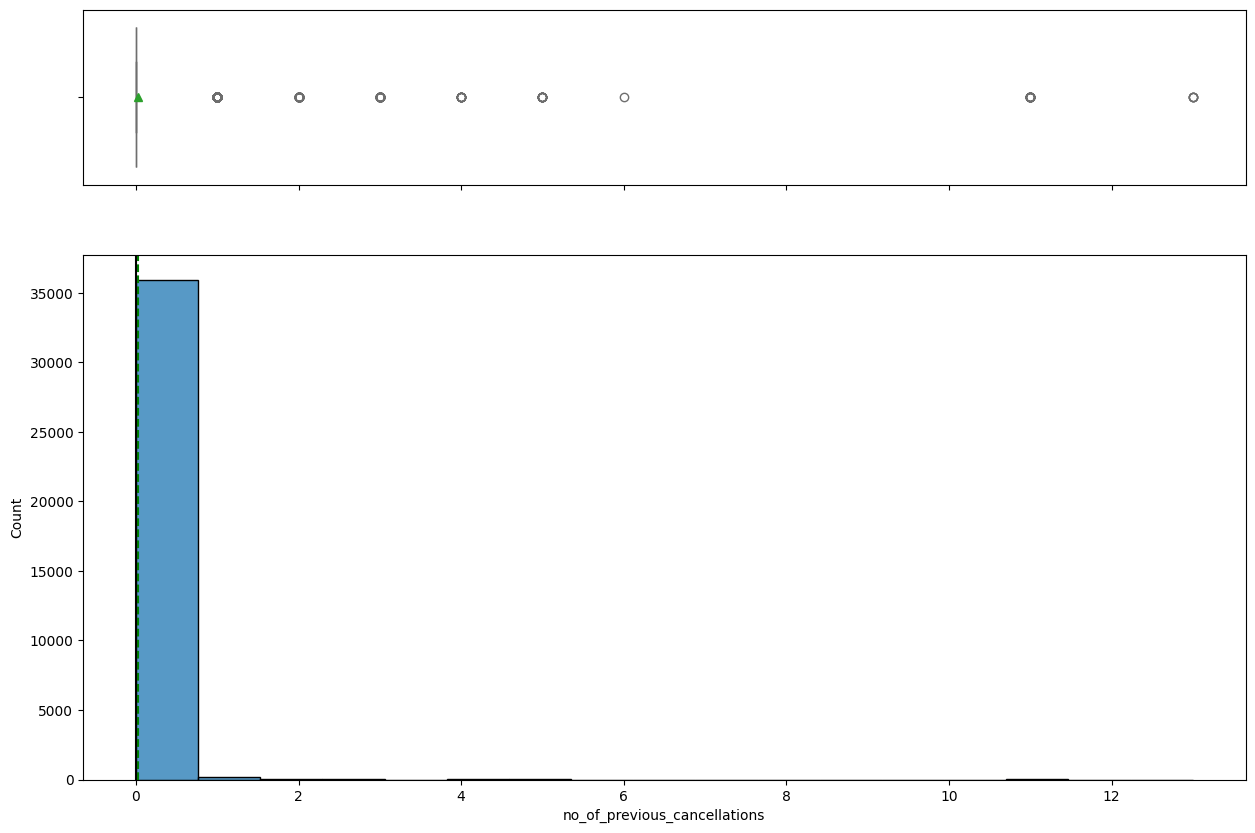

In [17]:
histogram_boxplot(data,'no_of_previous_cancellations')

# Observations of no_of_previous_cancellations

The distribution is heavily skewed to the right, indicating that most customers have not had previous cancellations.

There are a small number of customers with a high number of previous cancellations, which appear as outliers.

The vast majority of customers have 0 previous cancellations.


# Observation on Number of Previous Booking not Cancelled

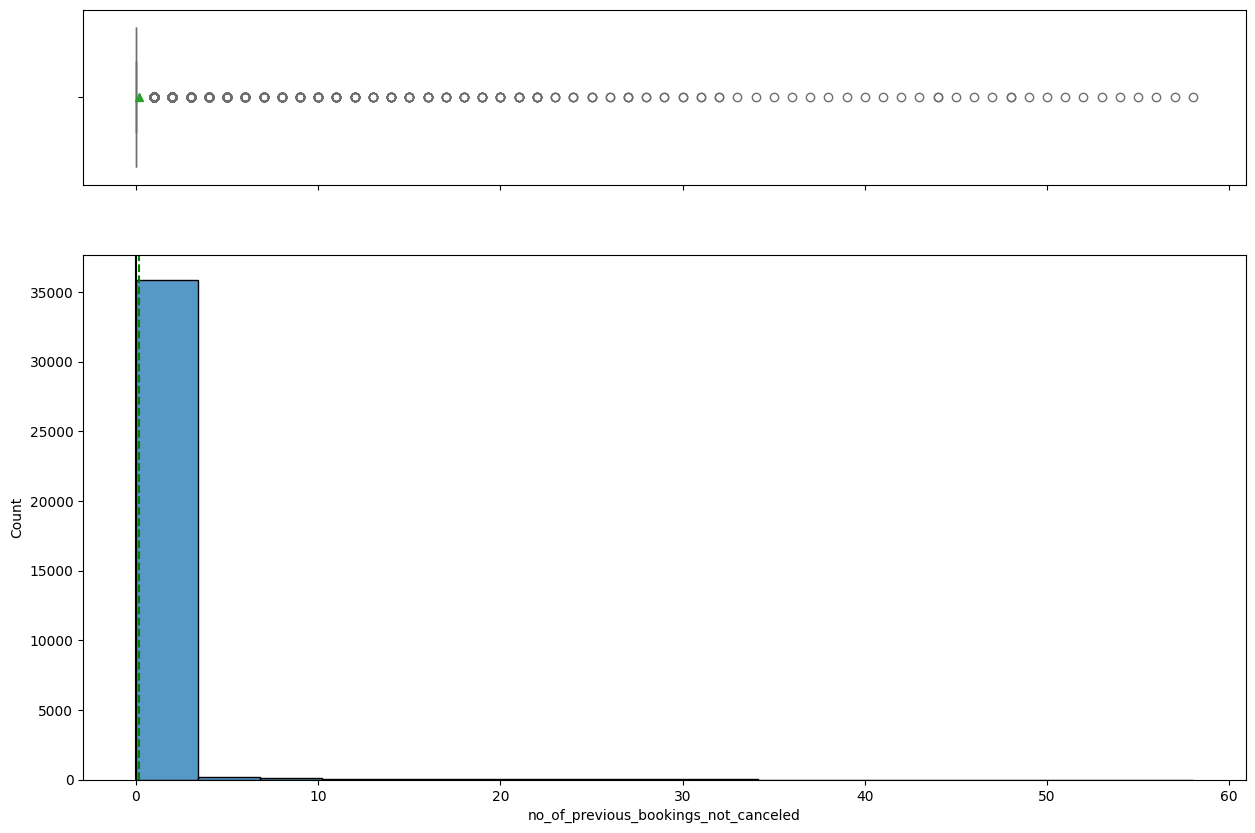

In [18]:
histogram_boxplot(data,'no_of_previous_bookings_not_canceled')

# Observation on Number of Previous Bookings not Cancelled

The distribution is heavily skewed to the right, indicating that most customers have not had previous bookings that were not canceled.

There are a small number of customers with a high number of previous non-canceled bookings, which appear as outliers.

The vast majority of customers have 0 previous non-canceled booking

# Function to Create labeled Barplots

In [19]:
#Function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
      plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot
        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot


# Observation on Number of Adults

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


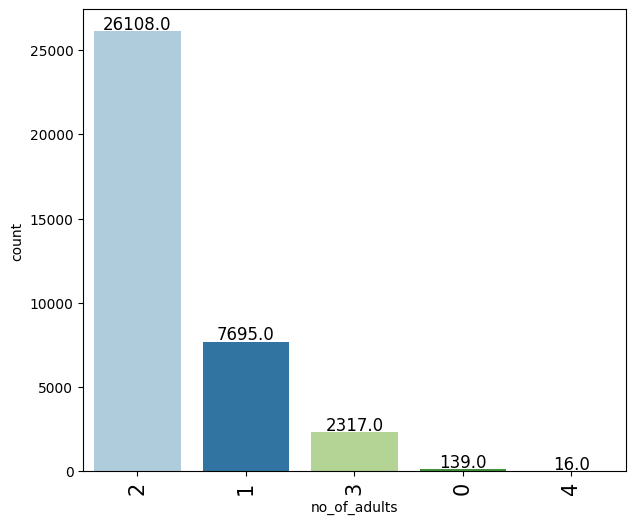

In [20]:
labeled_barplot(data,'no_of_adults')

# Observation:
The bar plot shows the distribution of the number of adults in the bookings.
The majority of bookings are for 2 adults.

There are also a significant number of bookings for 1 adult .

Bookings with 0, 3, or 4 adults are less common.

The hotel maybe an attractive place for couples and single travellers.


# Observation on Number of Children

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


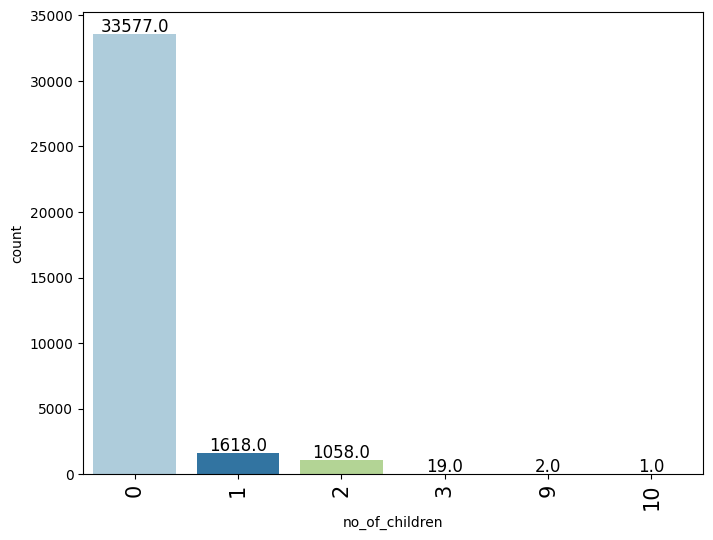

In [21]:
labeled_barplot(data,'no_of_children')


# Observation on Number of Children

The bar plot shows that most bookings have 0 children.

Bookings with 1 or 2 children are less frequent.

There are very few bookings with more than 2 children.

# Observations on Number of Week Nights

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


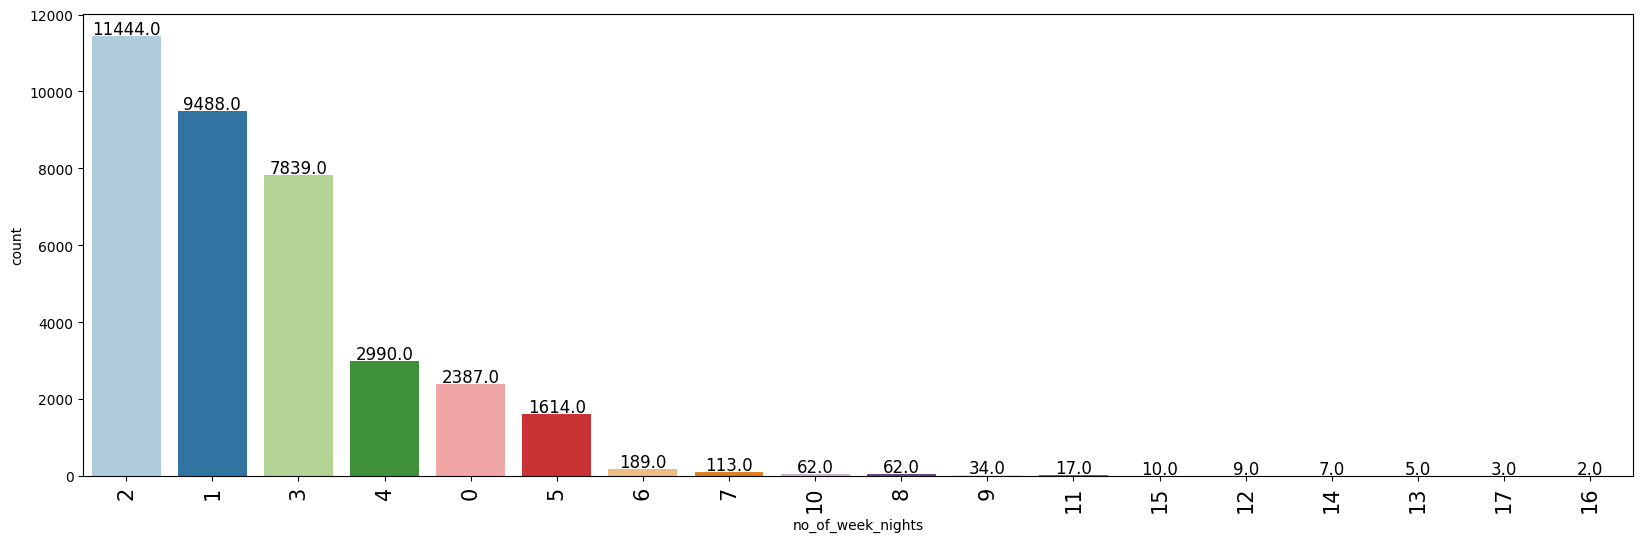

In [22]:
labeled_barplot(data,'no_of_week_nights')

# Observations on Number of Week Nights:

The majority of bookings are for 1 or 2 week nights.

Bookings for longer durations are less frequent.

The distribution is skewed towards shorter stays during week nights.

# Observation on Number of weekend Nights

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


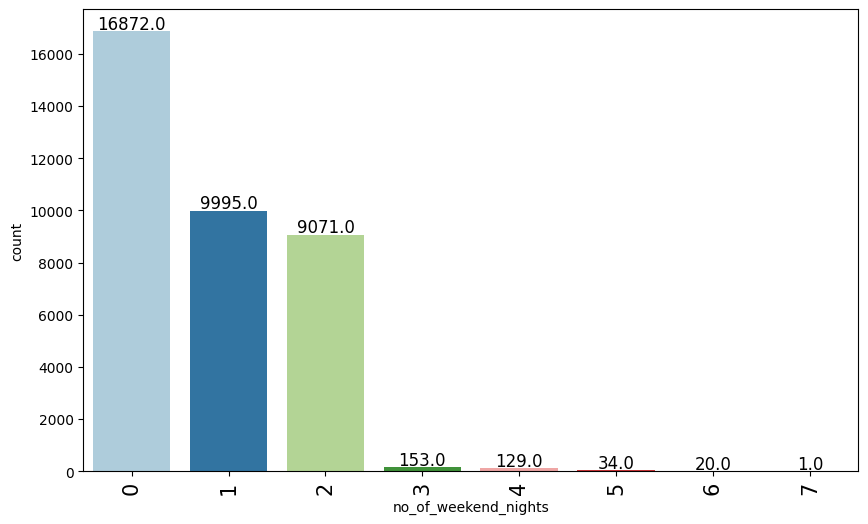

In [23]:
labeled_barplot(data,'no_of_weekend_nights')

# Observation:
The bar plot shows that mostky customers do not plan to spend the weekend in hotel
Bookings for 1 and 2 weekend nights almost the same.
The distribution is skewed towards shorter stays during weekend night.

# Observation on required Car Parking Space

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


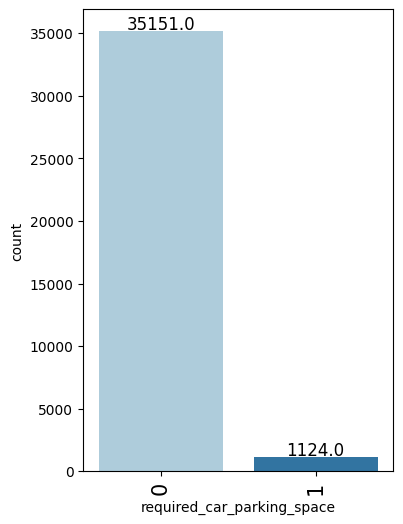

In [24]:
labeled_barplot(data,'required_car_parking_space')

# Observation on required Car Parking Space

The bar plot shows that the vast majority of bookings do not require a car parking space.
Only a small number of bookings request a car parking space.


# Observation on type of meal plan

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


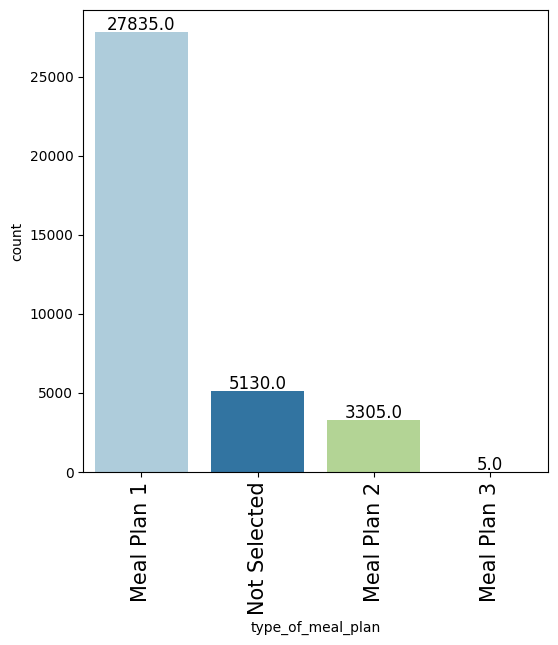

In [25]:
labeled_barplot(data,'type_of_meal_plan')

# Observation on type of meal plan
The bar plot shows the distribution of different meal plans.

Meal Plan 1 is the most frequently booked meal plan.

"Not Selected" is the second most frequent, followed by Meal Plan 2 and Meal Plan 3.


# Observation on room type reserved

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


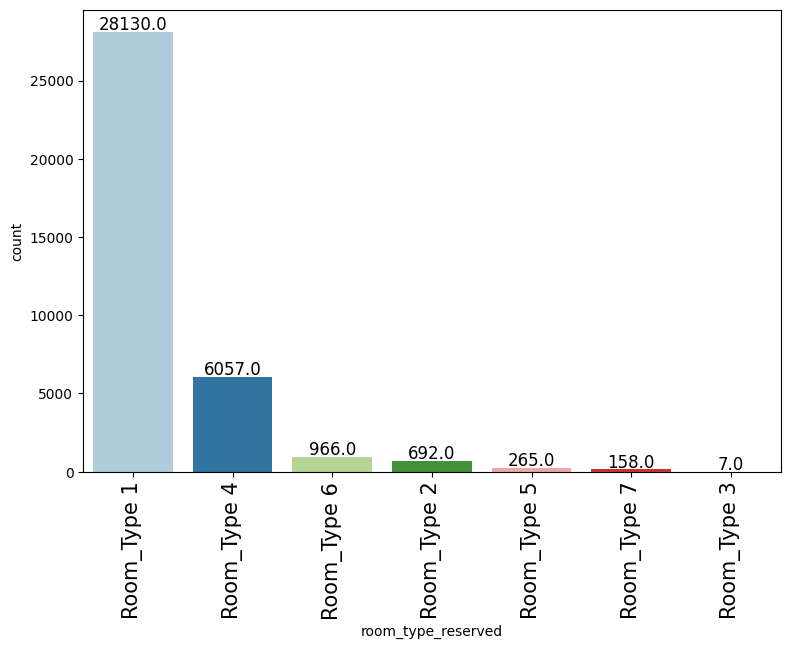

In [26]:
labeled_barplot(data,'room_type_reserved')

# Obervation on room type reserved

The bar plot shows that Room Type 1 is the most frequently reserved room type.

Other room types are reserved much less frequently.

There are a few room types with very low reservation counts.

# Obervation on Arrival month.

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


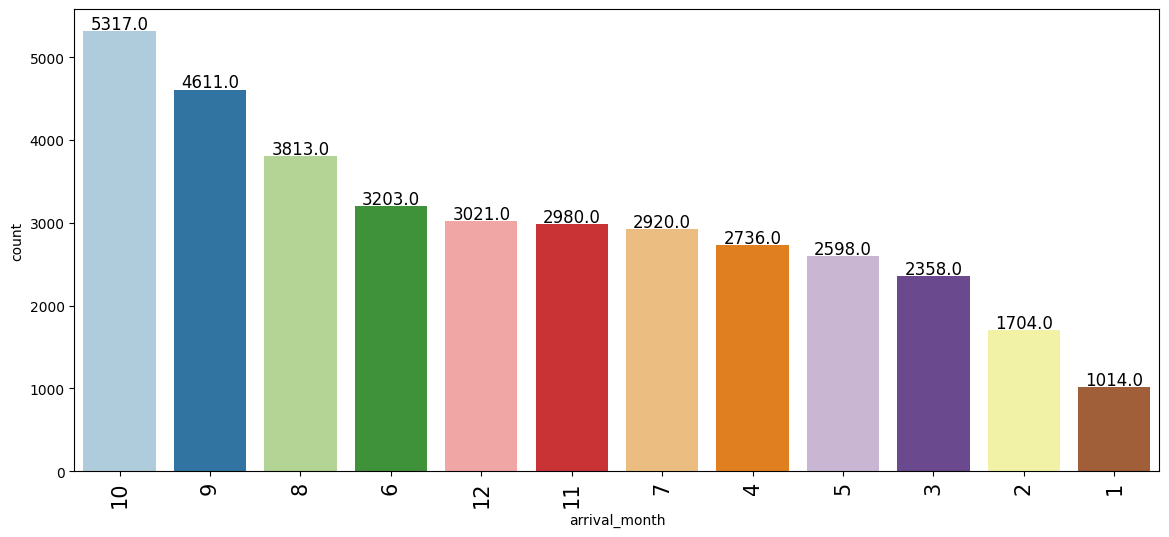

In [27]:
labeled_barplot(data,'arrival_month')

# Observation on Arrival month

The bar plot shows the distribution of bookings across different months of arrival.

The months with the highest number of bookings appear October followed by september and august.

There are fewer bookings in the earlier months of the year.

The distribution seems to follow a seasonal pattern, with more bookings in the latter half of the year.


# Observation on Market segment type.

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


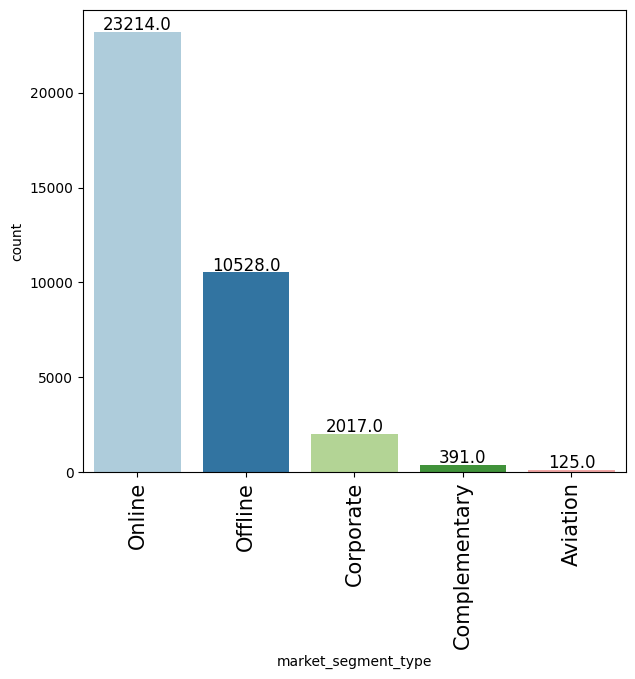

In [28]:
labeled_barplot(data,'market_segment_type')

# Observation on market segment type
The bar plot shows the distribution of bookings across different market segments.

Online is the most frequent market segment, followed by Offline and Corporate.

There are also a few bookings from other market segments like Complementary and Aviation.


# Observation on number of Special requests

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


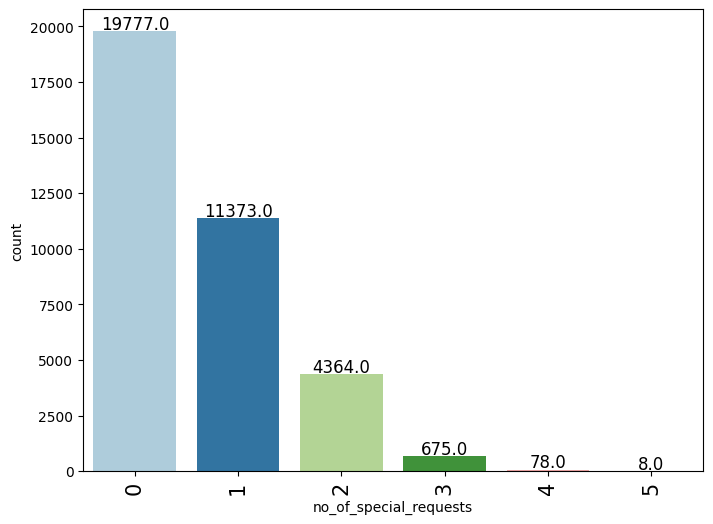

In [29]:
labeled_barplot(data,'no_of_special_requests')


# Observation on Number of special requests

The bar plot shows that the majority of bookings have no special requests.

A significant number of bookings have one special request.

Bookings with two or more special requests are less frequent.


# Observation on Booking status

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


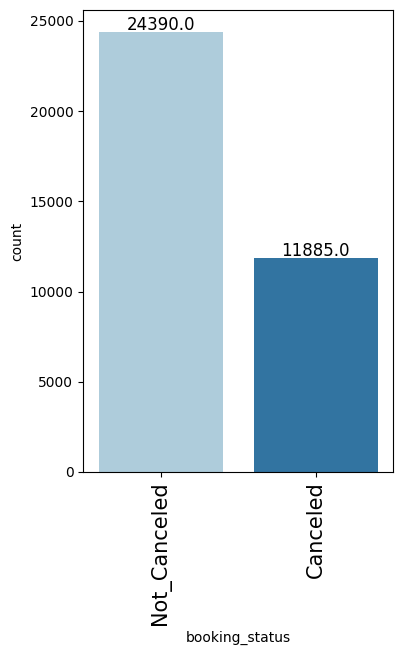

In [30]:
labeled_barplot(data,'booking_status')

# Observation on Booking status

The bar plot shows the distribution of booking statuses.

The majority of bookings are Not_Canceled.

A significant number of bookings are Canceled.


# Change not cancelled booking to 0 and cancelled booking as 1 for further analysis

In [31]:
#Change Not Cancelled booking to 0 and Cancelled booking as 1 for further analysis
data['booking_status'] = data['booking_status'].apply(lambda x: 1 if x == 'Canceled' else 0)

# Observation on correlation matrix into numerical variables

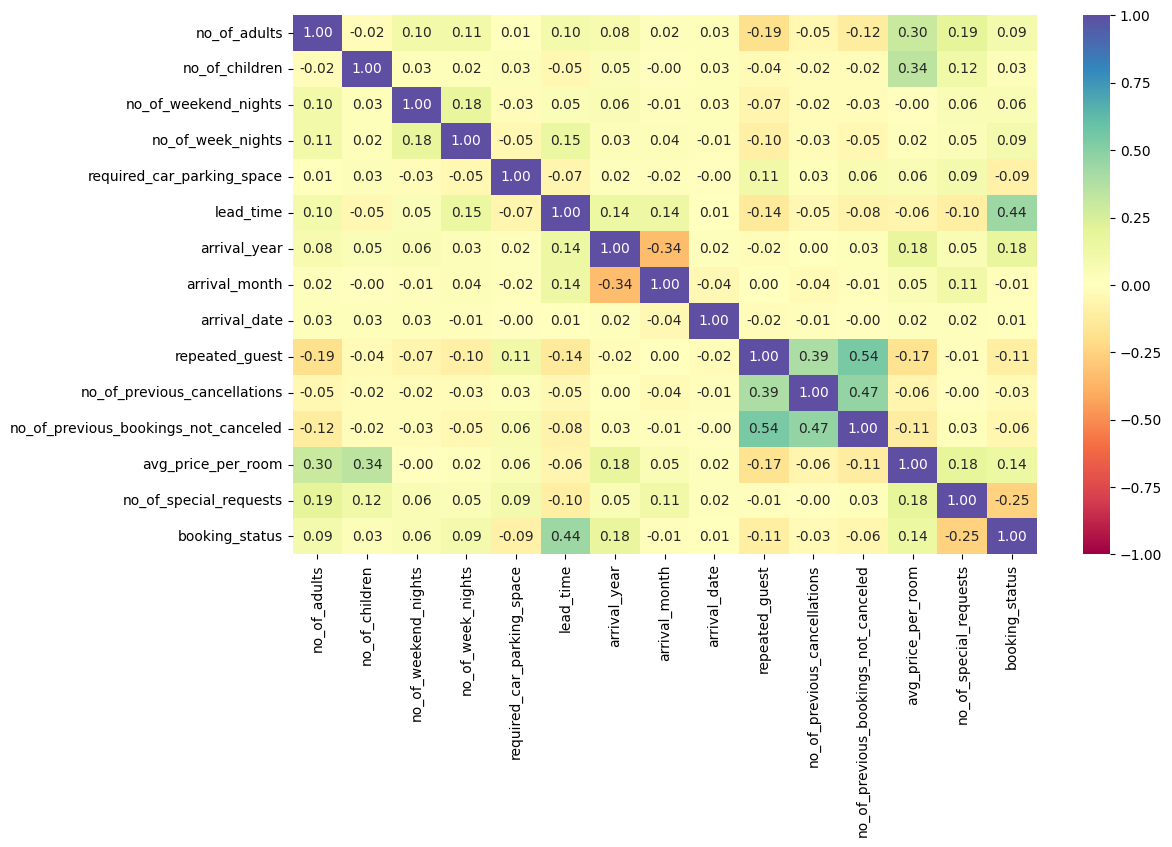

In [32]:
cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(12,7))
sns.heatmap(data[cols_list].corr(),annot=True,vmin=-1,vmax=1,fmt='.2f',cmap='Spectral')
plt.show()


# Observations on the heatmap

Lead Time and Booking Status: There is a moderate positive correlation between lead_time and booking_status. This suggests that bookings made further in advance are more likely to be canceled.

Number of Special Requests and Booking Status: There is a moderate negative correlation between no_of_special_requests and booking_status. This indicates that bookings with more special requests are less likely to be canceled.

Average Price Per Room: avg_price_per_room shows some correlation with lead_time, which might indicate that bookings made further in advance or for certain periods have different pricing.

Previous Cancellations and Repeated Guest: no_of_previous_cancellations and repeated_guest show a positive correlation, which is expected as repeated guests might have a history of cancellations.

Previous Bookings Not Canceled and Repeated Guest: no_of_previous_bookings_not_canceled and repeated_guest also show a positive correlation, which is expected as repeated guests are likely to have previous non-canceled bookings.

Number of Adults, Children, Weekend Nights, and Week Nights: These variables show some positive correlations with each other, which is intuitive as they relate to the size and duration of the booking.

Other correlations: Most other variables have weak correlations with booking_status. There is positive correlation between the number of customers and average price per room.More the number of customers more room they will require thus increase the cost.

There is negative correlation between average room price and repeated guests.The hotel might be going some loyalty benefits to the customers.

There is a positive correlation between lead time and number of weeknights a customer is planning to stay in the hotel.

Lead time shows a positive association with booking cancellation, indicating that bookings made further in advance tend to have a higher likelihood of cancellation.



# Function For Creating Distribution plot w_r_t target and stacked bar plot

In [33]:
#Creating functions that will help with further analysis
def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

In [34]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
       )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

# Bivariate analysis on average_price_per_room and market_segment_type

/tmp/ipykernel_917/171889114.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,x='market_segment_type',y='avg_price_per_room',palette='gist_rainbow')


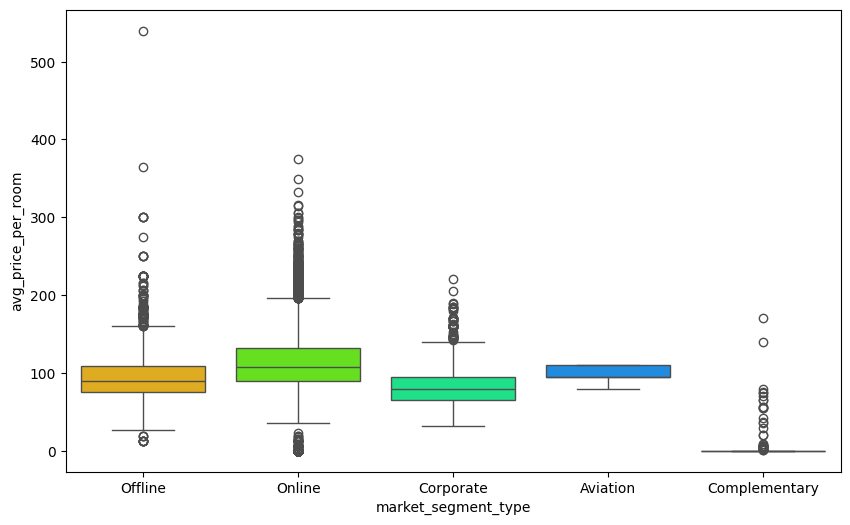

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='market_segment_type',y='avg_price_per_room',palette='gist_rainbow')
plt.show()


# Observation:
Online and Offline Segments: The "Online" and "Offline" market segments have a wide range of average prices, with the median price being relatively similar for both. This suggests that these segments include a variety of booking types with different pricing.

Corporate Segment: The "Corporate" segment appears to have a lower median average price per room compared to "Online" and "Offline". The spread of prices is also smaller. This could indicate negotiated corporate rates.

Complementary Segment: The "Complementary" segment shows an average price of 0, which aligns with the earlier observation that some rooms are given for free.

Aviation Segment: The "Aviation" segment has a relatively higher median average price per room and a smaller spread compared to "Online" and "Offline". This might be due to specific contracts or booking patterns related to the aviation industry.

Overall: The boxplot highlights the differences in pricing strategies and booking behaviors across different market segments.



# Bivariate analysis on Booking status and Market segment type

booking_status           0      1    All
market_segment_type                     
All                  24390  11885  36275
Online               14739   8475  23214
Offline               7375   3153  10528
Corporate             1797    220   2017
Aviation                88     37    125
Complementary          391      0    391
------------------------------------------------------------------------------------------------------------------------


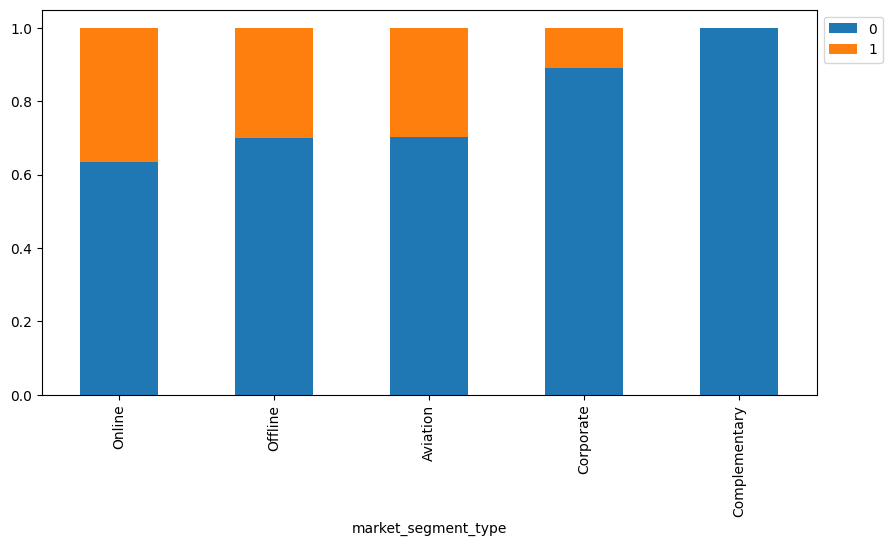

In [36]:
stacked_barplot(data,'market_segment_type','booking_status')

# Observation
Online Segment: The "Online" market segment has the highest number of both canceled and non-canceled bookings. It also appears to have a significant proportion of cancellations compared to some other segments.

Offline Segment: The "Offline" segment also contributes a substantial number of bookings, with a lower proportion of cancellations compared to the "Online" segment.

Corporate Segment: The "Corporate" segment has a very low cancellation rate compared to "Online" and "Offline" segments. This suggests that corporate bookings are less likely to be canceled.
Complementary Segment: The "Complementary" segment has no cancellations. This is expected as these rooms are likely given for free or as part of a special arrangement.

Aviation Segment: The "Aviation" segment has a relatively higher cancellation rate compared to the "Corporate" and "Complementary" segments, but lower than the "Online" segment.

Overall: The market segment type appears to have an influence on the booking status. The "Online" segment has the highest volume of cancellations, while "Corporate" and "Complementary" segments have very low cancellation rate.

# Bivariate analysis on Booking status and Number of special requests


booking_status              0      1    All
no_of_special_requests                     
All                     24390  11885  36275
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
------------------------------------------------------------------------------------------------------------------------


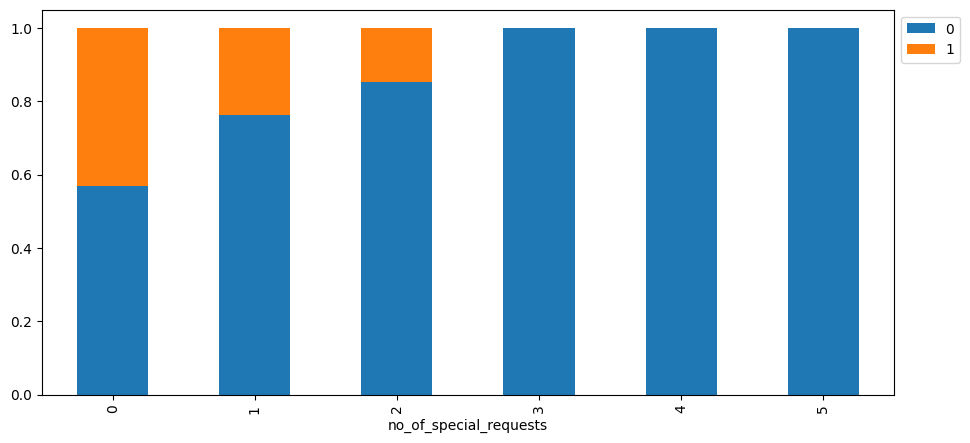

In [37]:
stacked_barplot(data,'no_of_special_requests','booking_status')


# Observation:

1.Bookings with no special requests have the highest cancellation proportion.

2.As the number of special requests increases, the proportion of cancellations generally decreases.

3. Bookings with 3 or more special requests have no cancellations in this dataset.

4.This suggests a negative association between the number of special requests and booking cancellation, although it does not establish causation.

# Bivariate analysis on Average price per room and number of special requests


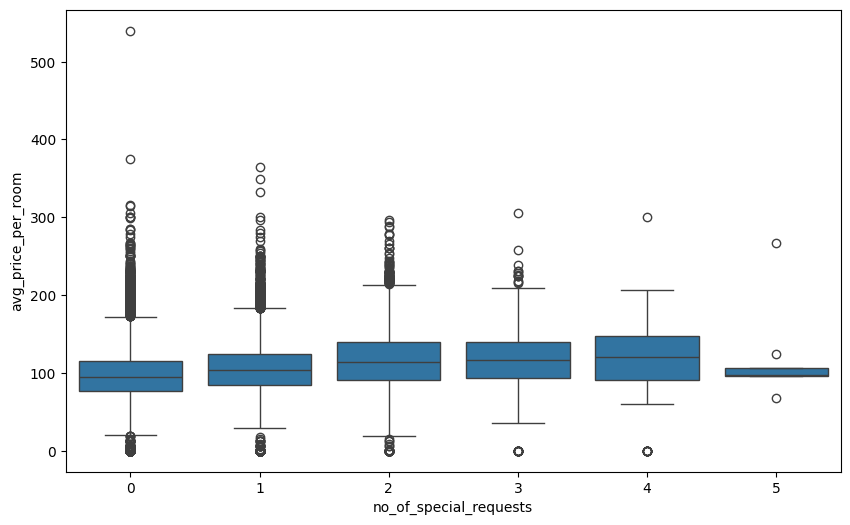

In [38]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='no_of_special_requests',y='avg_price_per_room')
plt.show()

# Observations:
Trend with Special Requests: There appears to be a slight upward trend in the median average price per room as the number of special requests increases. Bookings with more special requests tend to have slightly higher average prices.

Spread of Prices: The spread of average prices (indicated by the interquartile range) seems to be relatively similar across different numbers of special requests, although there might be some variations.



# Bivariate analysis on average_price_per_room and booking_status

/tmp/ipykernel_917/3560522804.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
/tmp/ipykernel_917/3560522804.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


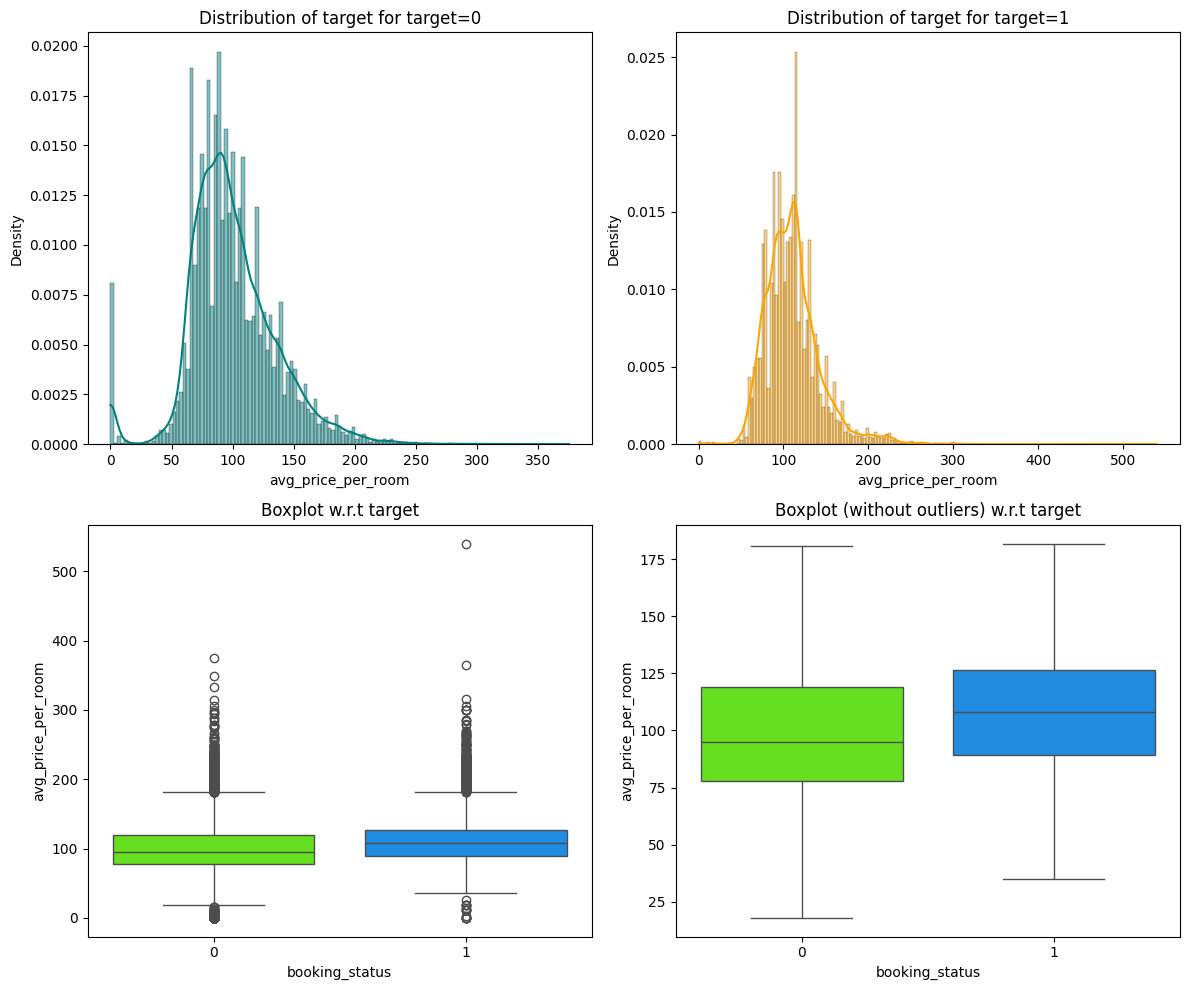

In [39]:
distribution_plot_wrt_target(data, 'avg_price_per_room', 'booking_status')

# Observations:

Distribution Shape: Both the distribution of average price per room for canceled and not-canceled bookings appear to be right-skewed, with a concentration of values at the lower end and a tail extending towards higher prices.

Median and Mean: The boxplots show that the median and mean average price per room for canceled bookings are slightly higher than for not-canceled bookings. This suggests that bookings with higher average prices might have a slightly higher propensity to be canceled.

Outliers:There are outliers in both groups, indicating some bookings with exceptionally high average prices regardless of their cancellation status.

# Bivariate analysis on lead time and booking status
There is positive correlation between booking status and lead time also.Let's analyze it further

/tmp/ipykernel_917/3560522804.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")
/tmp/ipykernel_917/3560522804.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


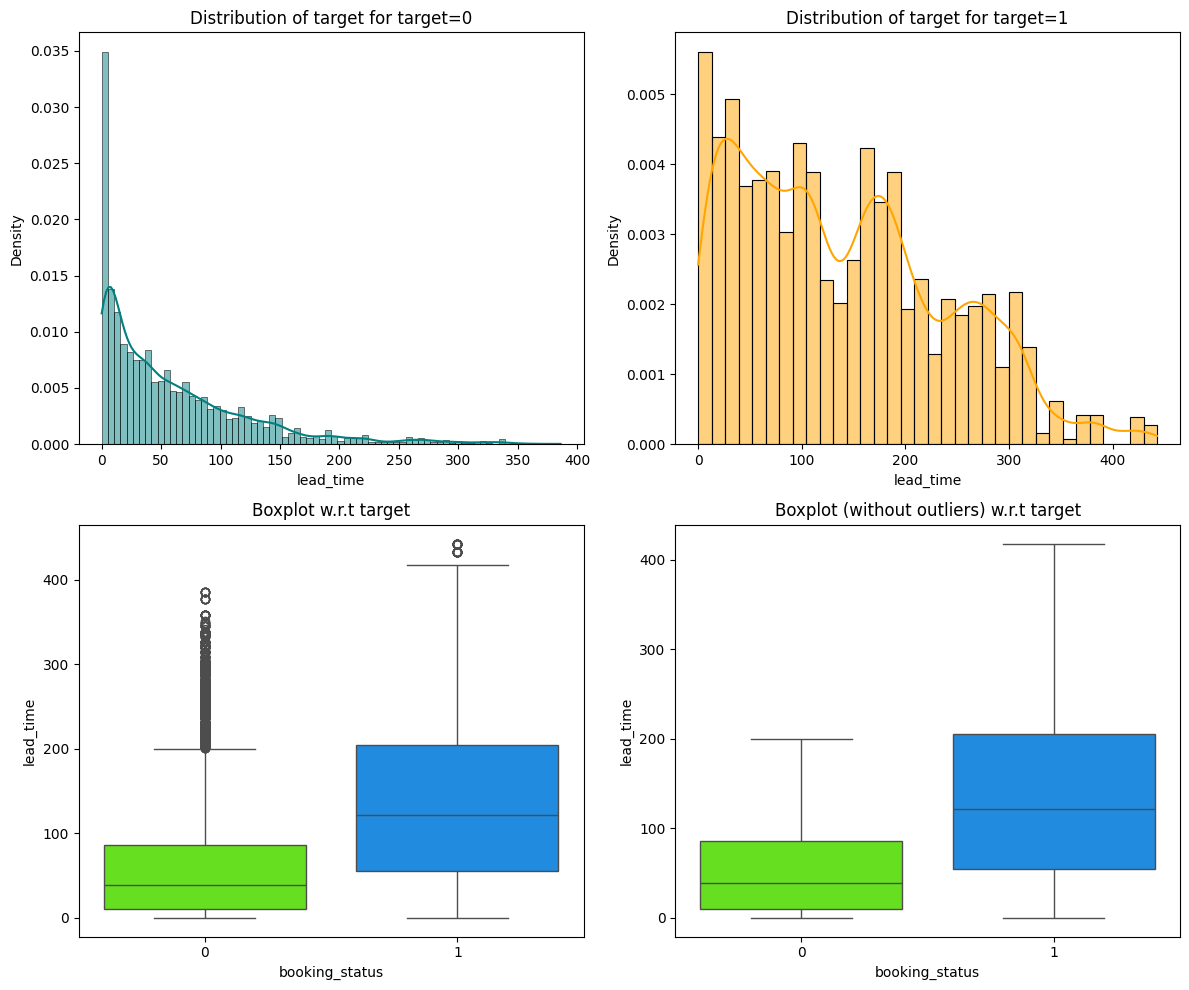

In [40]:
distribution_plot_wrt_target(data, 'lead_time', 'booking_status')

# Observations:
Distribution Shape: Both the distribution of lead time for canceled and not-canceled bookings are heavily right-skewed, indicating that most bookings, regardless of status, have shorter lead times.

Median and Mean: The boxplots show that the median and mean lead time for canceled bookings are significantly higher than for not-canceled bookings. This indicates that bookings made further in advance are more likely to be canceled.

Outliers: Both groups have outliers with very long lead times, but these extreme values are more prevalent in the canceled bookings.



# Bivariate analysis on Number of family members and booking status
Generally people travel with their spouse and children for vacations or other activities.So a new dataframe has been created of the customers who travelled with their families and analyze the impact on booking status.

In [41]:
family_data = data[(data['no_of_children']>=0) & (data['no_of_adults']>1)]
family_data.shape

(28441, 18)

In [42]:
family_data['no_of_family_members'] = (family_data['no_of_children'] + family_data['no_of_adults'])

/tmp/ipykernel_917/2713990376.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  family_data['no_of_family_members'] = (family_data['no_of_children'] + family_data['no_of_adults'])


booking_status            0     1    All
no_of_family_members                    
All                   18456  9985  28441
2                     15506  8213  23719
3                      2425  1368   3793
4                       514   398    912
5                        10     5     15
11                        0     1      1
12                        1     0      1
------------------------------------------------------------------------------------------------------------------------


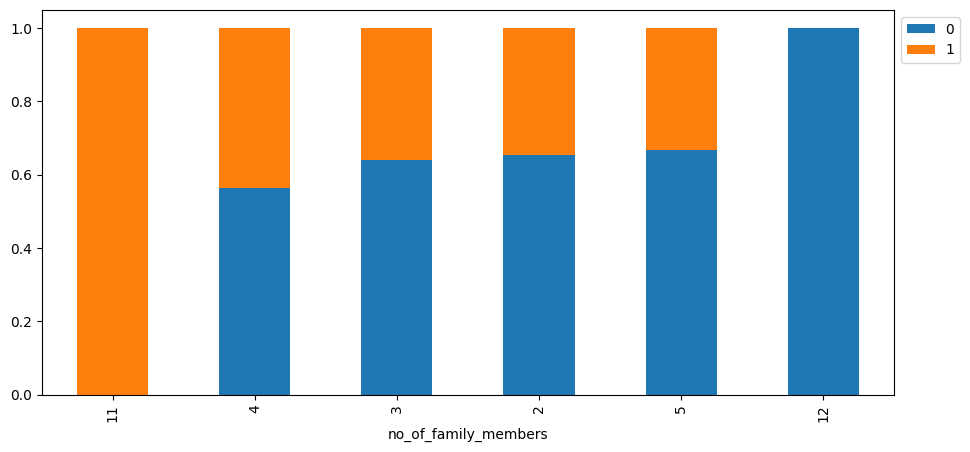

In [43]:
stacked_barplot(family_data,'no_of_family_members','booking_status')

# Observations:

Two Family Members: Bookings with two family members (likely couples) constitute the largest group in this filtered data and have a significant number of both canceled and not-canceled bookings. The proportion of cancellations appears to be notable in this group.

Three or More Family Members: As the number of family members increases to three or more, the total number of bookings decreases.

Cancellation Proportion: While the raw counts decrease for larger family sizes, the proportion of canceled bookings within each group of 3 or more family members seems to be relatively similar to or slightly lower than the proportion for bookings with two family members.


# Bivariate analysis on Total days and Booking Status

In [44]:
day_data = data[(data['no_of_week_nights']>0) & (data['no_of_weekend_nights']>0)]
day_data.shape

(17094, 18)

In [45]:
day_data['total_days'] = (day_data['no_of_week_nights'] + day_data['no_of_weekend_nights'])

/tmp/ipykernel_917/1129859342.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  day_data['total_days'] = (day_data['no_of_week_nights'] + day_data['no_of_weekend_nights'])


booking_status      0     1    All
total_days                        
All             10979  6115  17094
3                3689  2183   5872
4                2977  1387   4364
5                1593   738   2331
2                1301   639   1940
6                 566   465   1031
7                 590   383    973
8                 100    79    179
10                 51    58    109
9                  58    53    111
14                  5    27     32
15                  5    26     31
13                  3    15     18
12                  9    15     24
11                 24    15     39
20                  3     8     11
19                  1     5      6
16                  1     5      6
17                  1     4      5
18                  0     3      3
21                  1     3      4
22                  0     2      2
23                  1     1      2
24                  0     1      1
------------------------------------------------------------------------------------------

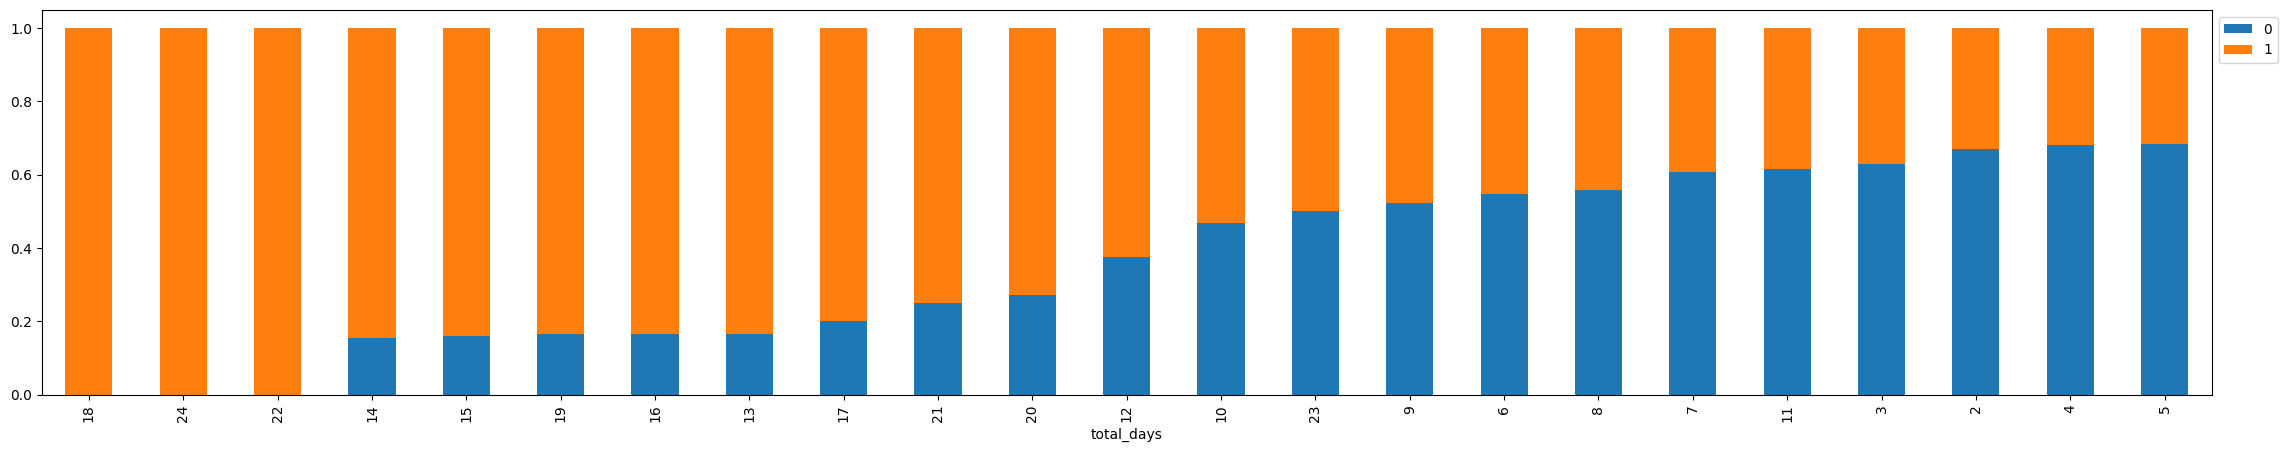

In [46]:
stacked_barplot(day_data,'total_days','booking_status')

# Observation:
 The more days a person stays, the less likely of cancellation

# Bivariate analysis on arrival month and booking status

booking_status      0      1    All
arrival_month                      
All             24390  11885  36275
10               3437   1880   5317
9                3073   1538   4611
8                2325   1488   3813
7                1606   1314   2920
6                1912   1291   3203
4                1741    995   2736
5                1650    948   2598
11               2105    875   2980
3                1658    700   2358
2                1274    430   1704
12               2619    402   3021
1                 990     24   1014
------------------------------------------------------------------------------------------------------------------------


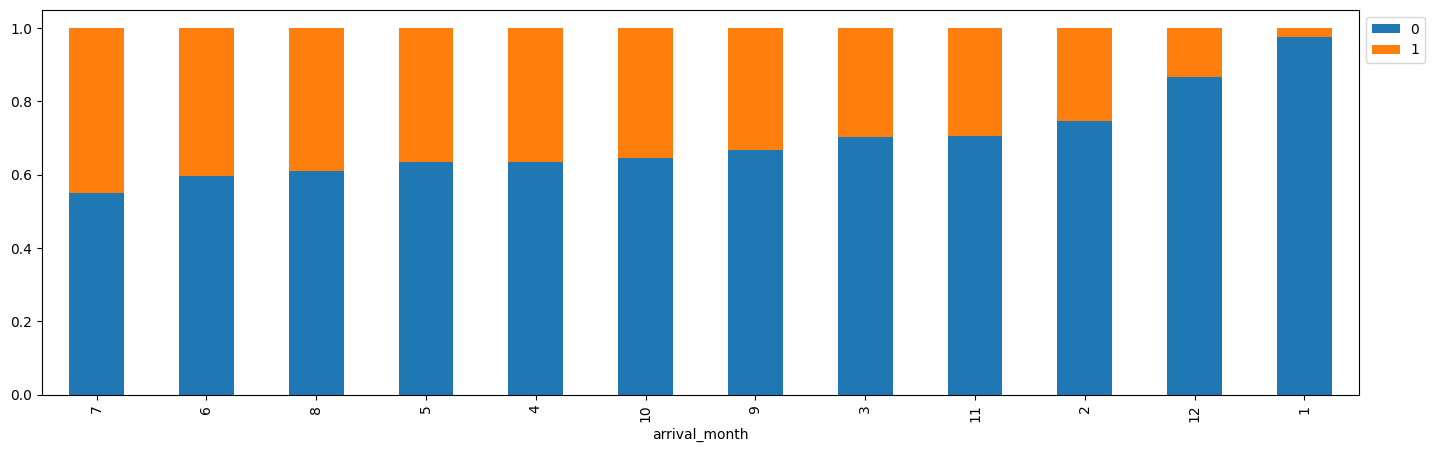

In [47]:
stacked_barplot(data,'arrival_month','booking_status')

# Observation:

This bar graph show arrival of guest according to month.

Highest no of guest come in october,then september and august.

Fewer guest come in december and january.

# Bivariate analysis on repeated guests & booking status

booking_status      0      1    All
repeated_guest                     
All             24390  11885  36275
0               23476  11869  35345
1                 914     16    930
------------------------------------------------------------------------------------------------------------------------


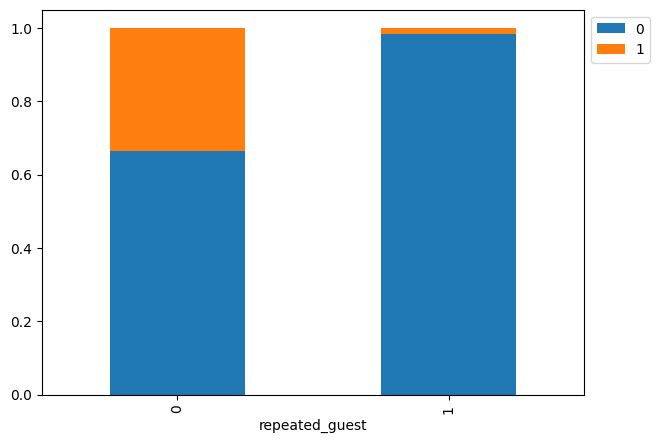

In [48]:
stacked_barplot(data,'repeated_guest','booking_status')

# Observation on repeated guests and booking status
The stacked bar plot clearly shows that the vast majority of bookings are from guests who are not repeated guests (indicated by '0').

Repeated guests ('1') account for a very small proportion of the total bookings.

More importantly, the proportion of canceled bookings is significantly lower for repeated guests compared to guests who are not repeated guests.

 This suggests that repeated guests are much less likely to cancel their bookings.

This is a strong indication that fostering customer loyalty can help reduce booking cancellations.

# Bivariate analysis on Number of guests per month and month


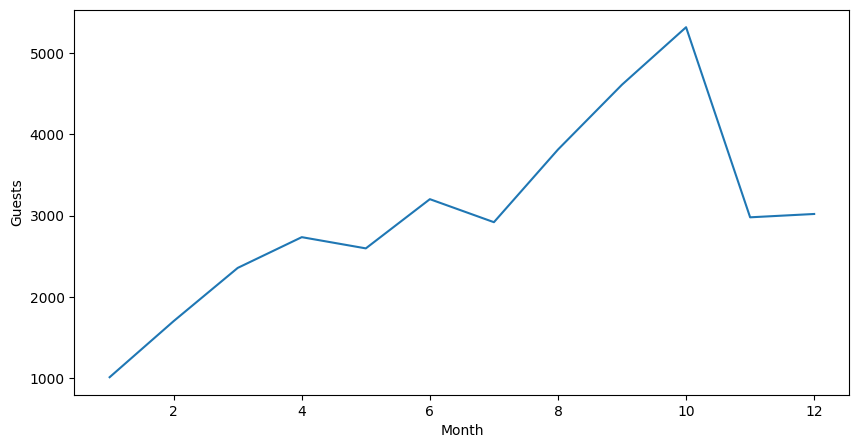

In [49]:
# grouping the data on arrival months and extracting the count of bookings
monthly_data = data.groupby(["arrival_month"])["booking_status"].count()

# creating a dataframe with months and count of customers in each month
monthly_data = pd.DataFrame(
    {"Month": list(monthly_data.index), "Guests": list(monthly_data.values)}
)

# plotting the trend over different months
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_data, x="Month", y="Guests")
plt.show()


# Observation:

This trend shows the number of bookings remain consistent from April to July and the hotel sees around 3000 to 3500 guests.

Most bookings were made in october-more than 5000 bookings.

Least bookings were made in january -around 1000 bookings.



# Bivariate analysis on Number of Cancellations and Month

booking_status      0      1    All
arrival_month                      
All             24390  11885  36275
10               3437   1880   5317
9                3073   1538   4611
8                2325   1488   3813
7                1606   1314   2920
6                1912   1291   3203
4                1741    995   2736
5                1650    948   2598
11               2105    875   2980
3                1658    700   2358
2                1274    430   1704
12               2619    402   3021
1                 990     24   1014
------------------------------------------------------------------------------------------------------------------------


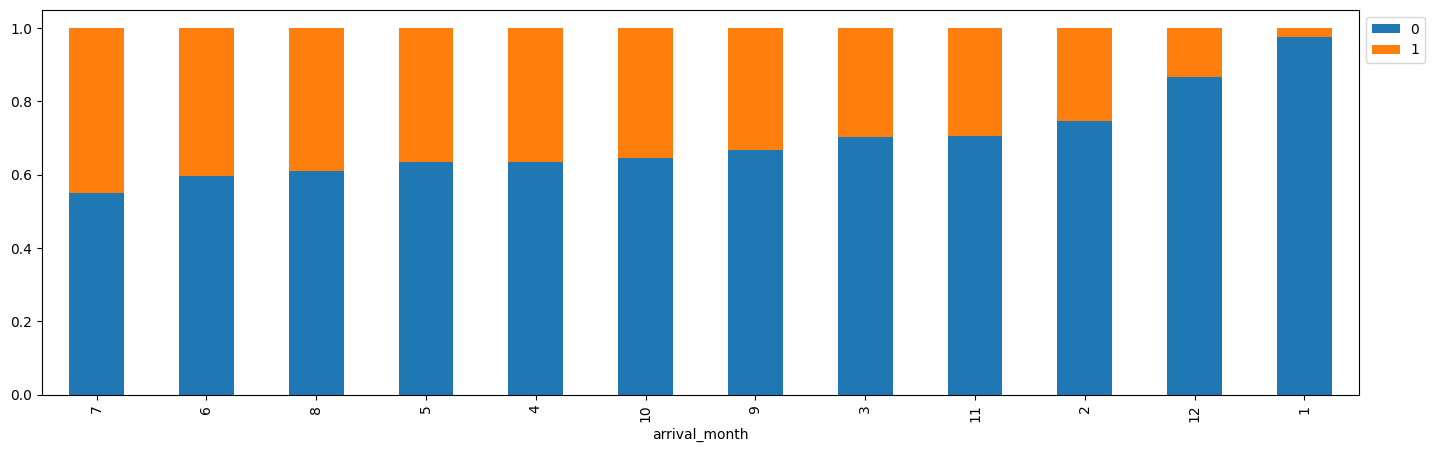

In [50]:
stacked_barplot(data,'arrival_month','booking_status')

# Observations:

The months with the highest number of total bookings (like October, September, and August) also tend to have a higher absolute number of cancellations.

# Prices of rooms across various months of the year

/tmp/ipykernel_917/1340841564.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', False)` for the same effect.

  sns.lineplot(data=data,x='arrival_month',y='avg_price_per_room',ci=False)


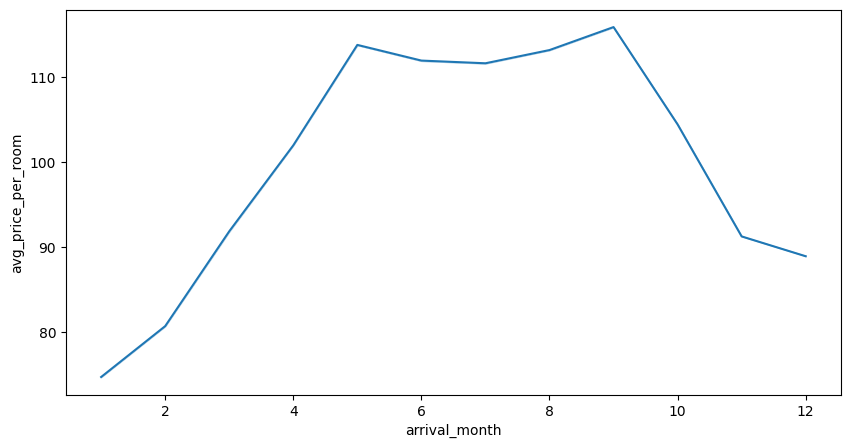

In [51]:
plt.figure(figsize=(10,5))
sns.lineplot(data=data,x='arrival_month',y='avg_price_per_room',ci=False)
plt.show()


# Observation:
Seasonal Variation: The average price per room shows a clear seasonal pattern. Prices tend to be lower in the earlier months of the year (January, February, March) and gradually increase, peaking during the summer months (July, August, September) and early autumn (October)

Peak Season: The highest average prices are observed in the months of August, September, and October, which likely correspond to peak tourist season.

Off-Peak Season: The lowest average prices are in January and February, suggesting these are off-peak months.

/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


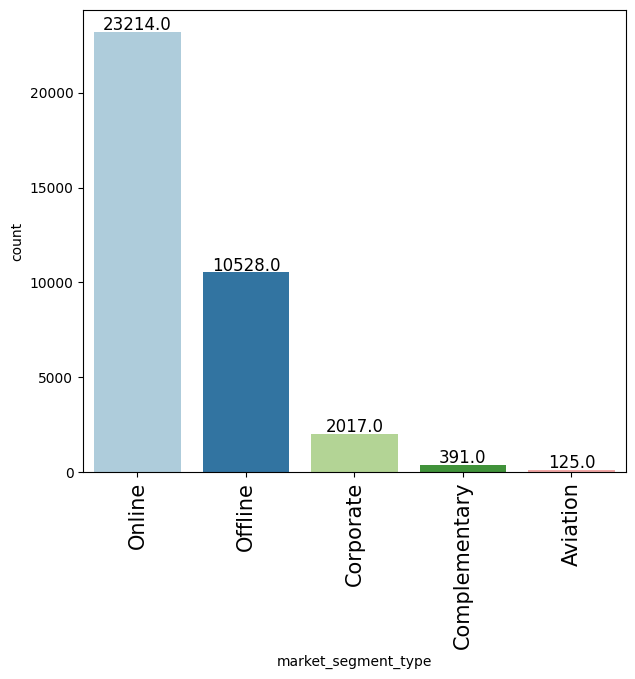

In [52]:
labeled_barplot(data, 'market_segment_type')

# Observation:

The Online market segment contributes the largest number of guests by a significant margin.

The Offline market segment is the second largest source of guests, but with considerably fewer bookings than the Online segment.

The Corporate segment has a moderate number of guests.

The Complementary and Aviation segments have a much smaller number of guests compared to the other segments.

# Stacked Bar Plot of Number of Special Requests by Booking Status

booking_status              0      1    All
no_of_special_requests                     
All                     24390  11885  36275
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
------------------------------------------------------------------------------------------------------------------------


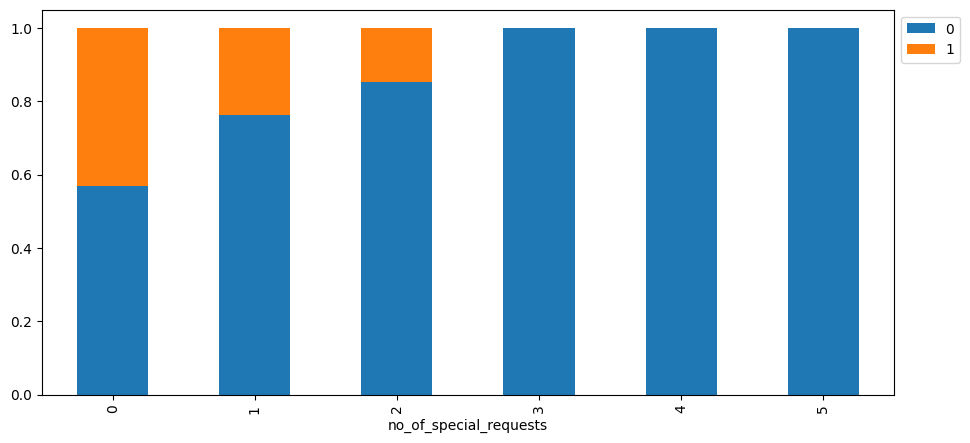

In [53]:
stacked_barplot(data,'no_of_special_requests','booking_status')

# Observation:

Bookings with no special requests have the highest number of cancellations. As the number of special requests increases, the proportion of cancellations generally decreases in this dataset. This suggests an association between the number of special requests and booking cancellation, although it does not establish causation.

# ScatterPlot

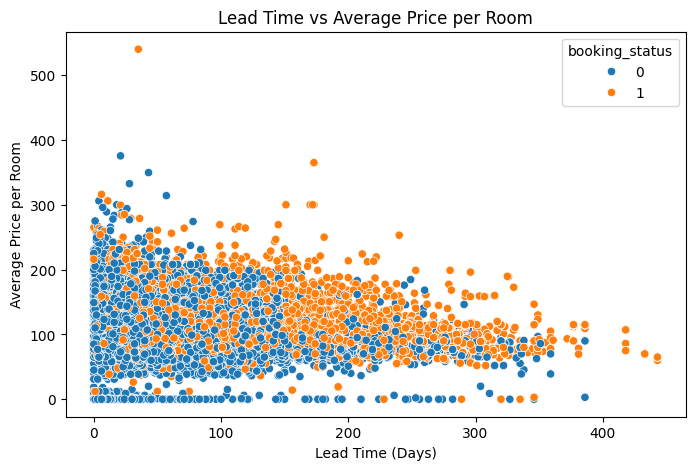

In [54]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x='lead_time',
    y='avg_price_per_room',
    hue='booking_status'
)

plt.title('Lead Time vs Average Price per Room')
plt.xlabel('Lead Time (Days)')
plt.ylabel('Average Price per Room')
plt.show()

# Observation:

1.The scatterplot shows that average room prices are widely distributed across different lead times.

2.As lead time increases, the concentration of observations generally shifts toward lower room prices.

3. Both canceled (1) and non-canceled (0) bookings are spread across the range, with considerable overlap between the two groups.

4.This suggests that lead time and room price do not have a strong linear relationship, although higher lead times are more frequently associated with moderate to lower room prices.

# PAIRPLOT

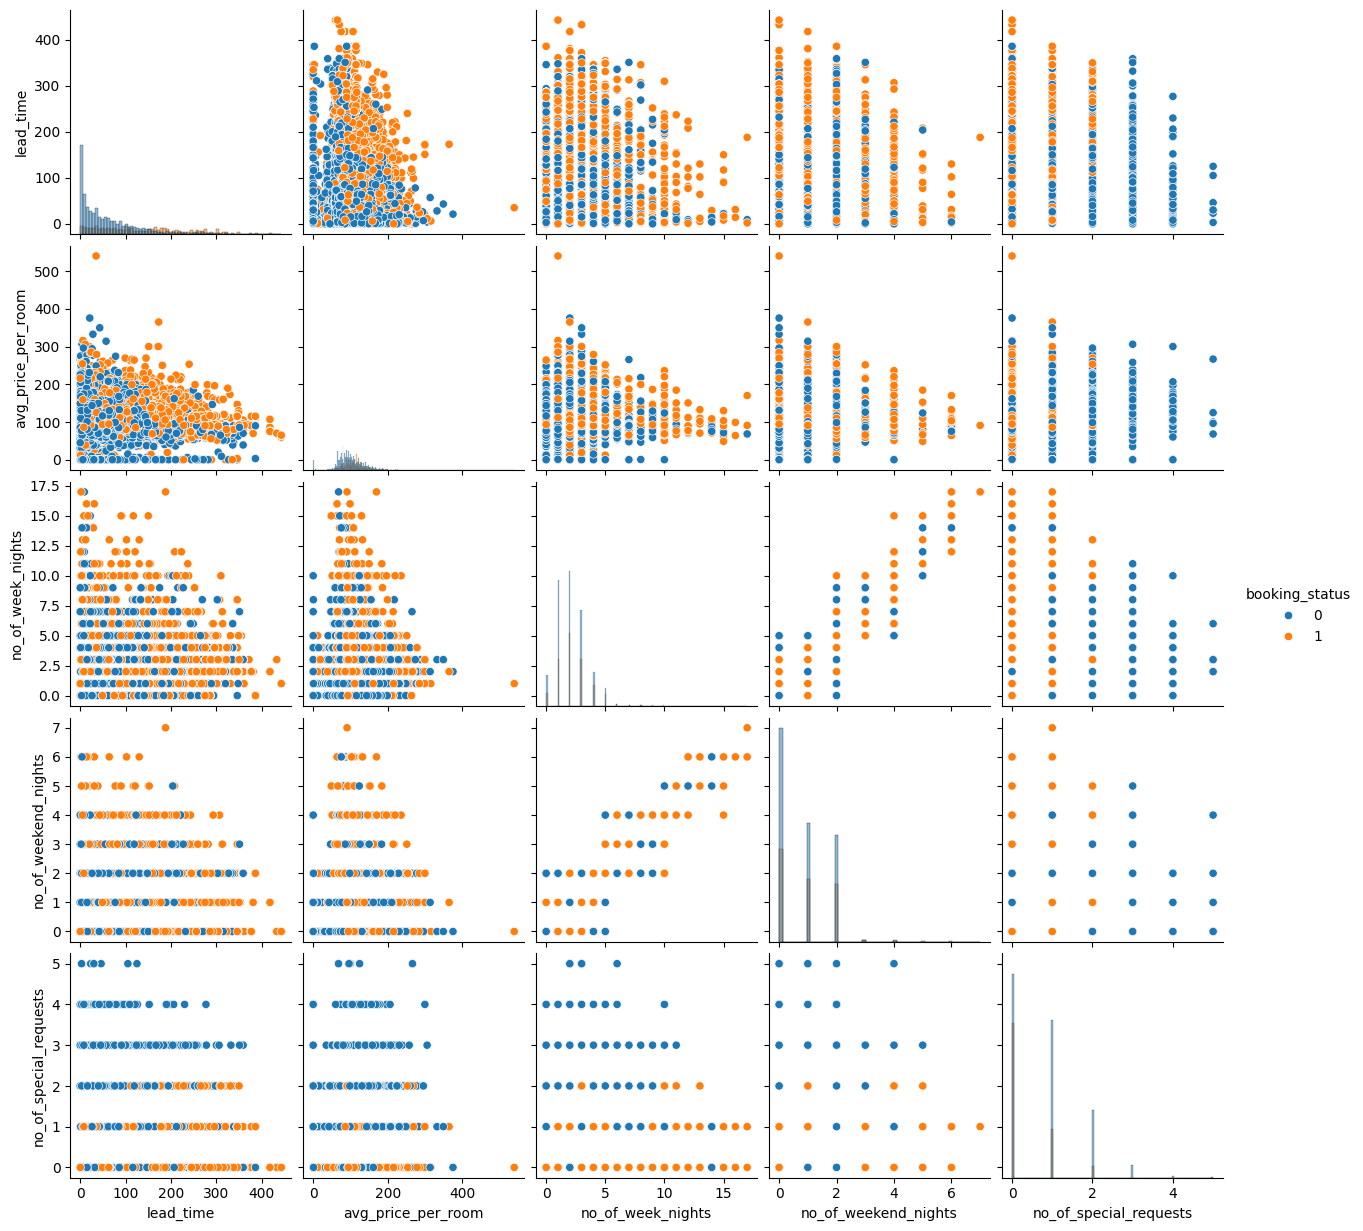

In [55]:
#PairPlot
pairplot_data = data[
    ['lead_time',
     'avg_price_per_room',
     'no_of_week_nights',
     'no_of_weekend_nights',
     'no_of_special_requests',
     'booking_status']
]

sns.pairplot(
    pairplot_data,
    hue='booking_status',
    diag_kind='hist'
)

plt.show()


# Observation:

1.The pairplot shows the relationships and distributions among the selected numerical variables, with observations separated by booking status.

2.Lead time and average price per room show a noticeable negative relationship, indicating that longer lead times are generally associated with lower room prices.

3.The number of week nights and weekend nights show relatively weak relationships with the other variables.

4.Booking status groups also show considerable overlap across most variable combinations, suggesting that no single numerical variable clearly separates canceled and non-canceled bookings.

# Q-1 What are the busiest months in the hotel

/tmp/ipykernel_917/3716319323.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=monthly_data, x="Month", y="Guests",palette='plasma')


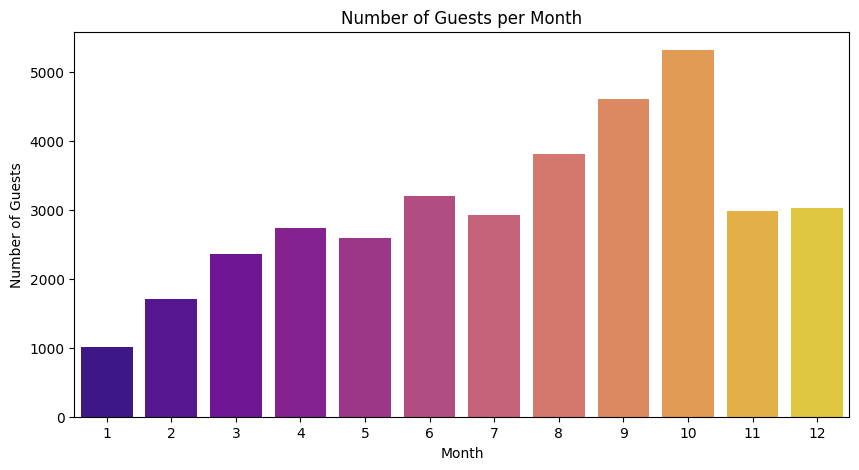

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_data, x="Month", y="Guests",palette='plasma')
plt.title("Number of Guests per Month")
plt.xlabel("Month")
plt.ylabel("Number of Guests")
plt.show()

# Observations:

The busiest months are October (10), September (9), and August (8), which have the highest number of bookings.

The number of bookings starts to increase from March (3) and remains relatively high throughout the summer and early autumn.



# Q-2 Which market segment do most of the guests come from?



/tmp/ipykernel_917/787504029.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


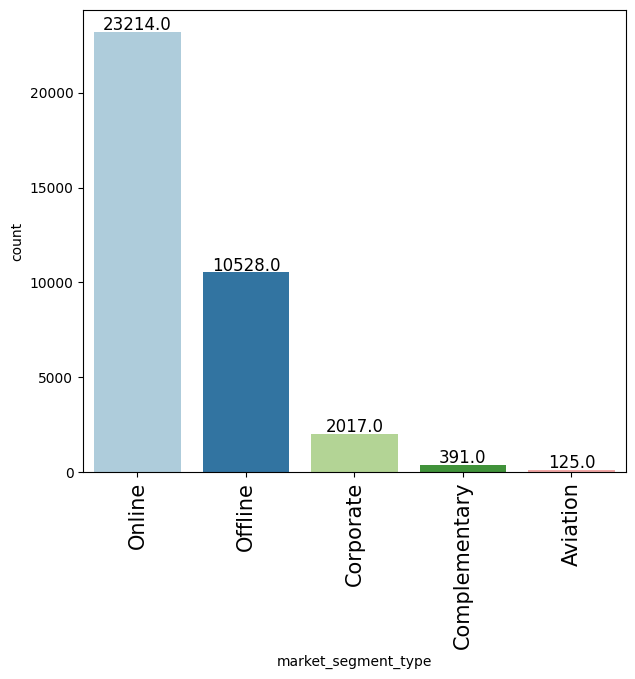

In [57]:
labeled_barplot(data, 'market_segment_type')

# Observation:

The Online market segment contributes the largest number of guests by a significant margin.

The Offline market segment is the second largest source of guests, but with considerably fewer bookings than the Online segment.

The Corporate segment has a moderate number of guests.

The Complementary and Aviation segments have a much smaller number of guests compared to the other segments.

# Q-3 What percentage of bookings are canceled?

In [58]:
canceled_percentage = data['booking_status'].mean() * 100
print(f"Percentage of canceled bookings: {canceled_percentage:.2f}%")

Percentage of canceled bookings: 32.76%


# Q-4 Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?

In [59]:
repeating_guests_data = data[data['repeated_guest'] == 1]
canceled_repeating_percentage = repeating_guests_data['booking_status'].mean() * 100
print(f"Percentage of canceled bookings by repeating guests: {canceled_repeating_percentage:.2f}%")

Percentage of canceled bookings by repeating guests: 1.72%


# Observation on repeated guests and booking status

The percentage of repeated guests who cancel is very low (1.72%). This further supports the idea that repeated guests are significantly less likely to cancel their bookings compared to the overall cancellation rate (32.76%). This highlights the value of customer loyalty in reducing cancellations.

# Q-5Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

booking_status              0      1    All
no_of_special_requests                     
All                     24390  11885  36275
0                       11232   8545  19777
1                        8670   2703  11373
2                        3727    637   4364
3                         675      0    675
4                          78      0     78
5                           8      0      8
------------------------------------------------------------------------------------------------------------------------


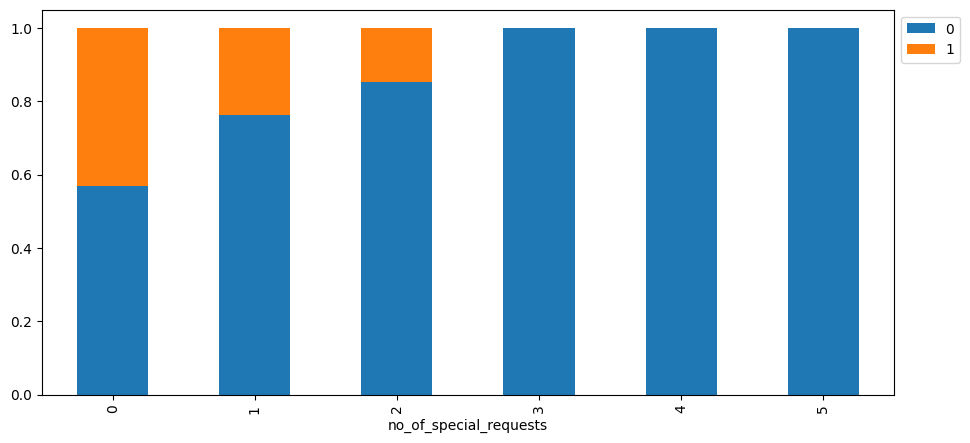

In [60]:
stacked_barplot(data,'no_of_special_requests','booking_status')

# Observation:

Bookings with no special requests have the highest number of cancellations. As the number of special requests increases, the proportion of cancellations generally decreases in this dataset. This suggests an association between the number of special requests and booking cancellation, although it does not establish causation.


# Q-6 Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?

/tmp/ipykernel_917/1211307904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data,x='market_segment_type',y='avg_price_per_room',palette='viridis')


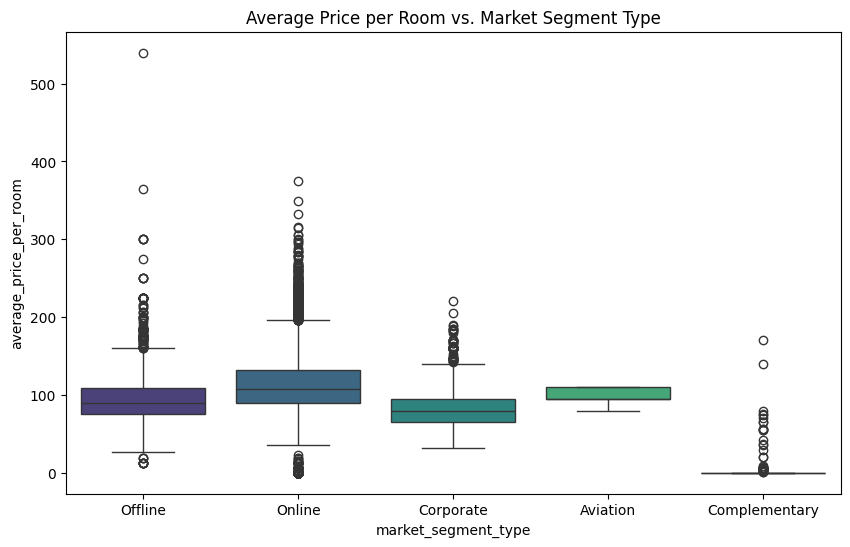

In [61]:
plt.figure(figsize=(10,6))
sns.boxplot(data=data,x='market_segment_type',y='avg_price_per_room',palette='viridis')
plt.title('Average Price per Room vs. Market Segment Type')
plt.xlabel('market_segment_type')
plt.ylabel('average_price_per_room')
plt.show()

# Observation:
Online and Offline Segments: The "Online" and "Offline" market segments have a wide range of average prices, with the median price being relatively similar for both. This suggests that these segments include a variety of booking types with different pricing.

Corporate Segment: The "Corporate" segment appears to have a lower median average price per room compared to "Online" and "Offline". The spread of prices is also smaller. This could indicate negotiated corporate rates.

Complementary Segment: The "Complementary" segment shows an average price of 0, which aligns with the earlier observation that some rooms are given for free.

Aviation Segment: The "Aviation" segment has a relatively higher median average price per room and a smaller spread compared to "Online" and "Offline". This might be due to "specific contracts or booking patterns related to the aviation industry.

# EDA Insights and Observation of each Variable

# Univariate Analysis:
Lead Time: Right-skewed, most bookings are made closer to arrival, outliers with long lead times exist.
Average Price per Room: Right-skewed, most prices are around 100 euros, outliers with very high prices, some bookings have zero price (complementary).
previous cancellations, outliers with high numbers of cancellations.

Number of Previous Bookings Not Canceled: Heavily right-skewed, most customers have no previous non-canceled bookings, outliers with high numbers of non-canceled bookings.

Number of Adults: Most bookings are for 2 adults, followed by 1 adult.

Number of Children: Most bookings have 0 children, few have more than 2.

Number of Week : Skewed towards shorter stays.
Number of Weekend Nights Skewed towards shorter stays, many customers don't stay over the weekend. Required Car Parking Space: Very few bookings require a car parking space. Type of Meal Plan: Meal Plan 1 is most frequent, followed by Not Selected.

Room Type Reserved: Room Type 1 is most frequent.
Arrival Month: Arrival Month: Higher number of bookings in the latter half of the year, peaking in October.
Market Segment Type: Online is the most frequent segment, followed by Offline and Corporate.

Number of Special Requests: Most bookings have no special requests, fewer have one or more.

Booking Status: About 32.76% of bookings are canceled.

# Bivariate Analysis:

Lead Time and Booking Status: Positive correlation, longer lead times associated with higher cancellation rates.

Number of Special Requests and Booking Status:
Negative association, with more special requests generally associated with lower cancellation rates.

Average Price per Room and Market Segment Type: Prices vary across segments, Corporate and Complementary have lower prices, Aviation has higher median price.

Booking Status and Market Segment Type: Cancellation rates vary across segments, Online has highest volume of cancellations, Corporate and Complementary have very low cancellation rates.

Average Price per Room and Number of Special Requests: Slight upward trend in average price with increasing special requests.

Average Price per Room and Booking Status: Bookings with higher average prices might have slightly higher cancellation rates.

Number of Family Members and Booking Status: Bookings with 2 family members have the highest number of cancellations, proportion of cancellations similar or slightly lower for larger families.

Total Stay Days and Booking Status: Shorter stays have a higher number of bookings and cancellations, proportion of cancellations relatively consistent across durations.

Repeated Guests and Booking Status: Repeated guests have a significantly lower cancellation rate (1.72%) compared to the overall rate (32.76%).

Number of Bookings per Month: Seasonal pattern, peaking in October.

Number of cancellations and Month: Months with higher total bookings also have higher absolute number of cancellations



# Data PreProcessing:

# Missing Value Treatment

In [62]:
data.isnull().sum()

,0
no_of_adults,0
no_of_children,0
no_of_weekend_nights,0
no_of_week_nights,0
type_of_meal_plan,0
required_car_parking_space,0
room_type_reserved,0
lead_time,0
arrival_year,0
arrival_month,0


There are no missing value in dataset.

# Outlier Detection and Treatment

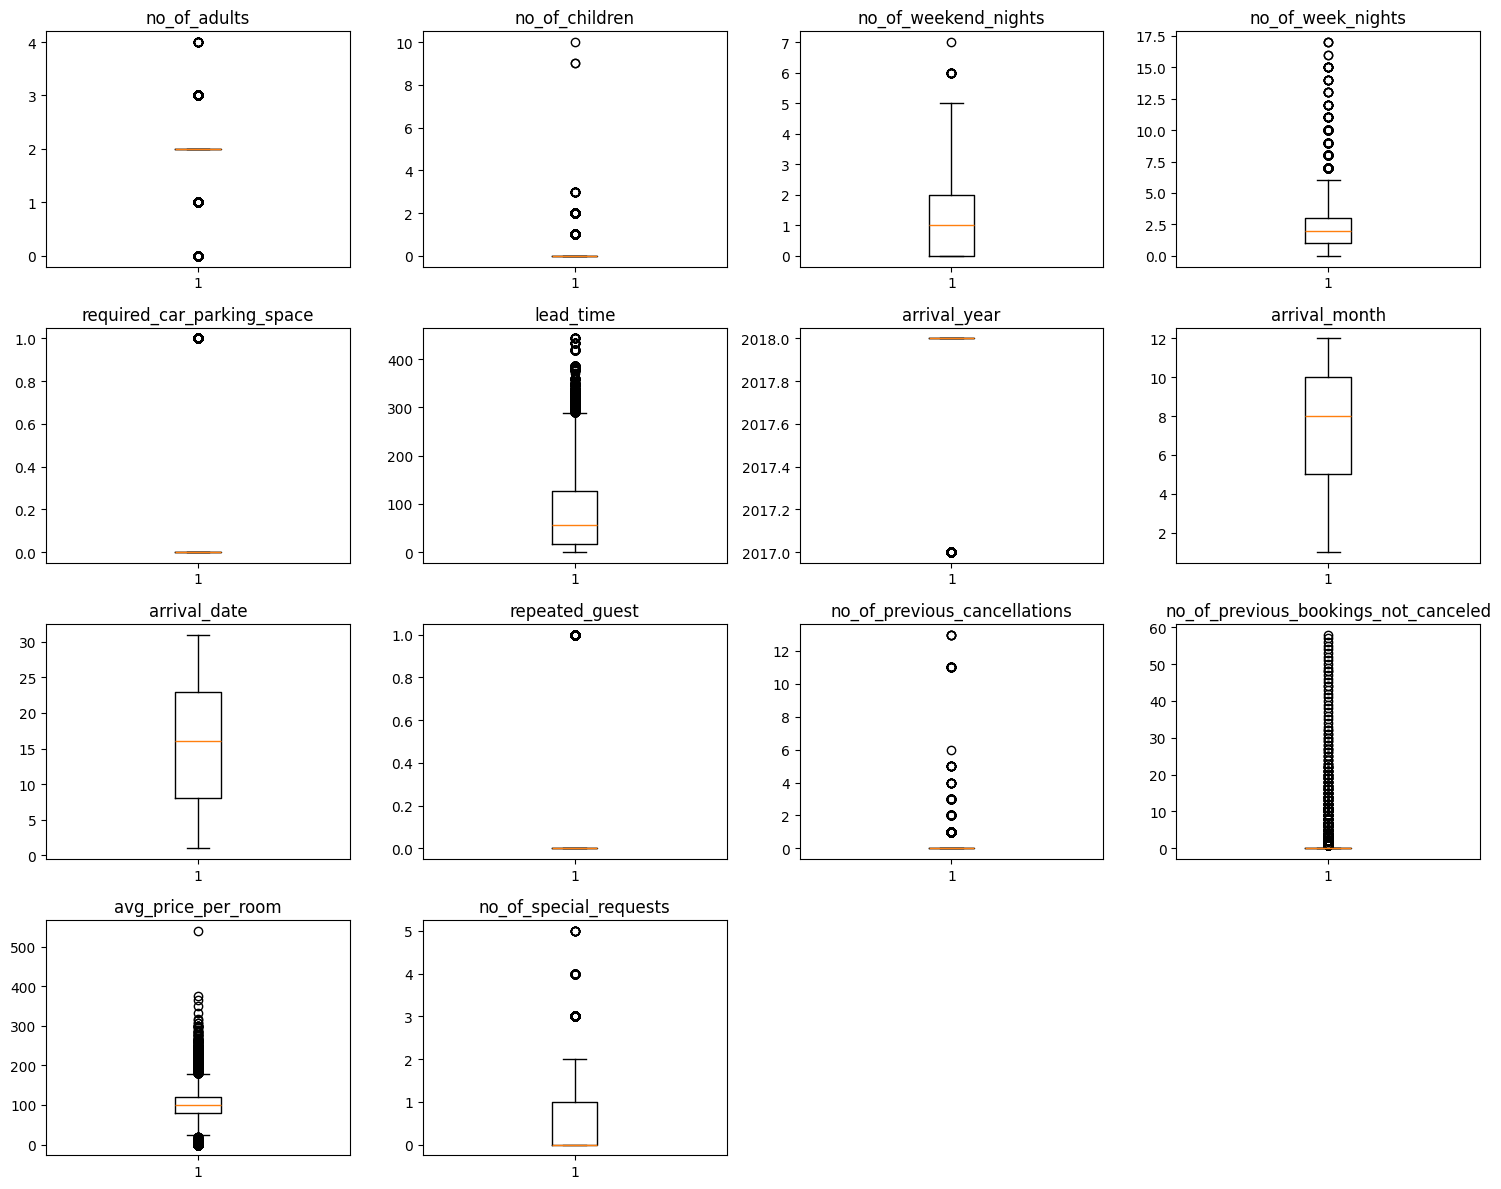

In [63]:
#Outlier detection using boxplot
numerical_cols = data.select_dtypes(include=np.number).columns.tolist()
#Dropping booking status
numerical_cols.remove('booking_status')
#Formula for outlier detection
plt.figure(figsize=(15,12))

for i, variable in enumerate(numerical_cols):
    plt.subplot(4,4,i+1)
    plt.boxplot(data[variable],whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

# Observation:

Although outliers exist,we will keep them as they may provide valuable information.
Extreme values were identified in average room price. These observations were retained because they may represent genuine differences in room pricing, market segments, or booking conditions.

# Final Summary of Findings

1. The hotel receives the highest number of bookings during October, followed by September and August, indicating higher booking activity during the later part of the year.

2. The Online market segment contributes the largest number of bookings, followed by Offline and Corporate segments.

3. Booking cancellation is an important issue, with approximately 32.76% of bookings being canceled.

4. Repeating guests have a much lower cancellation rate of approximately 1.72%, suggesting that loyal customers are less likely to cancel their bookings.

5. Bookings with special requests generally show a lower cancellation proportion than bookings without special requests.

6. Lead time is right-skewed, indicating that most bookings have relatively shorter lead times, while some bookings are made much further in advance.

7. Average room price is also right-skewed, with some extreme values and some complimentary bookings having a price of zero.

8. The correlation analysis indicates that lead time is positively associated with booking cancellation, while the number of special requests has a negative association with cancellation.

9. The analysis identified several outliers, but they were retained because they may represent genuine booking or pricing patterns.

Overall, the EDA highlights important patterns in booking volume, cancellation behavior, customer segments, lead time, room pricing, and guest requirements.